# 🎛️ Optuna — Hyperparameter Optimization That Learns Where to Look

> **What you'll learn:** what hyperparameters are and when tuning is worth it; grid vs random vs Bayesian search (TPE); writing objective functions and search spaces (log scales, conditional parameters); samplers, seeding, pruning, storage and parallel trials; multi-objective trade-offs with a Pareto front; tuning **without leakage**; and how to turn the best trial into a correct final model. You'll also build random search and TPE from scratch.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Gradient Boosting](../03_Classical_Machine_Learning/10_Gradient_Boosting.ipynb) (LightGBM, early stopping, validation sets) |
| **Tested with** | Python 3.12 · optuna 5.0 · lightgbm 4.7 · scikit-learn 1.9 · numpy 2.5 · pandas 3.0 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ High — "grid vs random vs Bayesian?", "how does TPE work?", "how do you avoid overfitting the validation set?", "what is pruning / Hyperband?", "how would you tune for accuracy *and* latency?" |

## 🤔 What Is Optuna?

Imagine tuning a guitar by ear. You don't try every possible peg position (that's **grid search**), and you don't twist pegs at random (that's **random search**). You pluck, listen, and move towards what sounds better. You also give up quickly on a string that is obviously way off.

**Optuna** does that for machine-learning settings:

- You write an **objective function**: "given these settings, train a model and return a score".
- A **sampler** proposes the next settings, **learning from all previous results** (by default with TPE, a Bayesian method).
- A **pruner** stops unpromising training runs early, so the time goes to good candidates.

```
  ┌─────────────── study ────────────────┐
  │  sampler ──► trial: {lr: 0.05, ...}  │
  │     ▲              │                 │
  │     │        objective(trial)        │
  │     │     train → report → (prune?)  │
  │     └──── score ◄──┘                 │
  └──────────────────────────────────────┘
```

Vocabulary: a **study** is one optimization session; a **trial** is one evaluation of the objective; a **search space** is the set of values each hyperparameter may take.

## 🎯 Why It Matters

- **Every model has knobs.** Learning rate, tree size, regularization, dropout, batch size, number of neighbours, chunk size in a RAG pipeline… Good values can be the difference between a mediocre and a strong model.
- **Compute is money.** Smart search plus pruning finds good settings in a fraction of the trials that grid search needs.
- **It's the industry default.** Optuna is widely used in Kaggle solutions and production ML pipelines, and the same ideas (TPE, Hyperband, ASHA) power Ray Tune, Weights & Biases sweeps, and cloud tuning services.
- **In interviews** you'll hear: *"Why is random search better than grid search?"*, *"Explain Bayesian optimization / TPE"*, *"How do you tune without leaking the test set?"*, *"Your tuned model is worse in production — why?"*, *"How would you trade off accuracy against latency?"*. This notebook answers each one with runnable evidence.

## ✅ By the End You Can

- [ ] Explain hyperparameters vs parameters, and decide when tuning is (and isn't) worth the compute
- [ ] Compare grid, random and Bayesian search, and explain how TPE chooses the next trial
- [ ] Write objectives with log-scaled, categorical and conditional search spaces, seeded for reproducibility
- [ ] Speed up studies with pruning, persist them in SQLite, resume them and run trials in parallel
- [ ] Run multi-objective studies and pick a model from the Pareto front
- [ ] Tune without leakage, recognise overfitting to the validation set, and map the best parameters into a correct final model

## 📋 Table of Contents

1. [Hyperparameters and Why Tuning Matters](#1.-Hyperparameters-and-Why-Tuning-Matters-🟢)
2. [Grid vs Random vs Bayesian Search](#2.-Grid-vs-Random-vs-Bayesian-Search-🟢)
3. [Your First Study: the Objective Function](#3.-Your-First-Study:-the-Objective-Function-🟢)
4. [Search Spaces: Log Scales, Categories and Conditional Parameters](#4.-Search-Spaces:-Log-Scales,-Categories-and-Conditional-Parameters-🟡)
5. [Samplers and Reproducibility](#5.-Samplers-and-Reproducibility-🟡)
6. [Pruning: Stop Bad Trials Early](#6.-Pruning:-Stop-Bad-Trials-Early-🟡)
7. [Storage, Resuming and Parallel Trials](#7.-Storage,-Resuming-and-Parallel-Trials-🟡)
8. [Multi-Objective Optimization and the Pareto Front](#8.-Multi-Objective-Optimization-and-the-Pareto-Front-🔴)
9. [Visualizing a Study](#9.-Visualizing-a-Study-🟢)
10. [Tuning Without Leakage — and Overfitting the Validation Set](#10.-Tuning-Without-Leakage-—-and-Overfitting-the-Validation-Set-🔴)
11. [From Best Trial to Final Model](#11.-From-Best-Trial-to-Final-Model-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Tuning-LightGBM-on-Adult-Income-the-Right-Way) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

Notes on choices you'll see:
- **Logging:** Optuna logs one line per trial. We set its verbosity to `WARNING` so outputs stay readable.
- **One targeted warning filter:** functions in `optuna.visualization.matplotlib` are marked *experimental* (their interface may change), so every call emits `ExperimentalWarning`. We filter that one warning class, and nothing else.
- **`LGBM_THREADS = 4`:** LightGBM uses every CPU thread by default. On this laptop that was **4× slower** on the Adult data than 4 threads (and ~40× slower for tiny datasets, where we use 1 thread), because thread coordination costs more than it saves.
- **Data:** the real **Adult census income** dataset from OpenML (48,842 people; predict income > \$50K), downloaded once and cached by scikit-learn. Split **60% train / 20% validation / 20% test**, stratified. The test set is used **only once**, at the very end of the mini project.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "optuna>=4.5" "lightgbm>=4.6" "scikit-learn>=1.6" "scipy>=1.13" "pandas>=2.2" matplotlib

import math
import subprocess
import sys
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
from optuna.trial import TrialState
from optuna.visualization import matplotlib as optuna_plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)   # matplotlib plots are "experimental"

print(f"Python {sys.version.split()[0]} | optuna {optuna.__version__} | lightgbm {lgb.__version__} | "
      f"scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

SEED = 42
LGBM_THREADS = 4
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
OPTUNA_DIR = OUTPUT_DIR / "optuna"
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

adult = fetch_openml("adult", version=2, as_frame=True)
X_all = adult.data
y_all = (adult.target == ">50K").astype(int).to_numpy()
X_trval, X_test, y_trval, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.25, stratify=y_trval, random_state=SEED)
print(f"rows: train {len(X_train):,} · validation {len(X_val):,} · test {len(X_test):,} (untouched until the end) | "
      f"positive rate {y_all.mean():.1%} | categorical columns: {X_all.select_dtypes('category').shape[1]}")


def check(name, got, expected, hint="", rel_tol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str, set, frozenset, dict)):
        ok = got == expected
    elif isinstance(expected, (tuple, list)):
        ok = len(got) == len(expected) and all(
            math.isclose(g, e, rel_tol=rel_tol) if isinstance(e, (int, float)) and not isinstance(e, bool) else g == e
            for g, e in zip(got, expected))
    else:
        ok = math.isclose(float(got), float(expected), rel_tol=rel_tol, abs_tol=1e-9)
    assert ok, f"❌ {name}: got {got!r}. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | optuna 5.0.0 | lightgbm 4.7.0 | scikit-learn 1.9.1 | numpy 2.5.3 | pandas 3.0.5
rows: train 29,304 · validation 9,769 · test 9,769 (untouched until the end) | positive rate 23.9% | categorical columns: 8


## 1. Hyperparameters and Why Tuning Matters 🟢

- **Parameters** are learned from data during training: a tree's split thresholds and leaf values, a neural network's weights.
- **Hyperparameters** are chosen *before* training and control *how* learning happens: `learning_rate`, `num_leaves`, `min_child_samples`, `n_estimators`, regularization strength.

Tuning means searching for hyperparameters that give the best score **on data the model hasn't trained on** (a validation set or cross-validation). Let's see how much they matter for LightGBM on Adult — and compare that to plain **noise** from changing only the random seed.

In [2]:
def val_auc(**params):
    model = lgb.LGBMClassifier(verbose=-1, n_jobs=LGBM_THREADS, **params).fit(X_train, y_train)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])


configs = {
    "LightGBM defaults": {},
    "too simple (stumps, slow)": dict(num_leaves=2, learning_rate=0.01, n_estimators=100),
    "too complex (overfits)": dict(num_leaves=1024, min_child_samples=1, learning_rate=0.3, n_estimators=500),
    "sensible hand-tuned": dict(num_leaves=31, learning_rate=0.05, n_estimators=400, colsample_bytree=0.8),
}
config_scores = {name: val_auc(random_state=SEED, **params) for name, params in configs.items()}
seed_scores = [val_auc(random_state=s, subsample=0.8, subsample_freq=1, colsample_bytree=0.8) for s in range(5)]

for name, score in config_scores.items():
    print(f"{name:28s} validation AUC {score:.4f}")
seed_noise = float(np.std(seed_scores))
spread = max(config_scores.values()) - min(config_scores.values())
gain_over_default = config_scores["sensible hand-tuned"] - config_scores["LightGBM defaults"]
print(f"\nspread between best and worst setting: {spread:.4f} AUC")
print(f"hand-tuned minus defaults            : {gain_over_default:+.4f} AUC")
print(f"seed-to-seed noise (std of 5 seeds)  : {seed_noise:.4f} AUC")
print("→ bad hyperparameters hurt a lot;", "the default-vs-tuned gain is bigger than seed noise." if abs(gain_over_default) > 2 * seed_noise
      else "but the gain over defaults is within ~2× seed noise, so don't over-invest in tuning here.")

LightGBM defaults            validation AUC 0.9302
too simple (stumps, slow)    validation AUC 0.8709
too complex (overfits)       validation AUC 0.9099
sensible hand-tuned          validation AUC 0.9306

spread between best and worst setting: 0.0597 AUC
hand-tuned minus defaults            : +0.0004 AUC
seed-to-seed noise (std of 5 seeds)  : 0.0004 AUC
→ bad hyperparameters hurt a lot; but the gain over defaults is within ~2× seed noise, so don't over-invest in tuning here.


**When tuning matters less:** gradient-boosting defaults are already decent, and **better data and features usually beat tuning**. With small datasets the validation score is noisy, so "improvements" can be luck (Section 10). Tune when bad settings are plausible, the metric's gain is worth the compute, and you can measure it reliably.

### ✍️ Your Turn

From the list below, put the names that are **hyperparameters** (chosen before training) into the set `hyperparameters`.

In [3]:
candidates = ["learning_rate", "leaf values", "num_leaves", "split thresholds", "n_estimators", "neural-network weights", "min_child_samples"]
hyperparameters = None  # TODO: a set of strings
check("hyperparameters", hyperparameters, {"learning_rate", "num_leaves", "n_estimators", "min_child_samples"},
      hint="Which ones would you type into the constructor, and which ones does .fit() learn?")

⏳ hyperparameters: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hyperparameters = {"learning_rate", "num_leaves", "n_estimators", "min_child_samples"}
check("hyperparameters", hyperparameters, {"learning_rate", "num_leaves", "n_estimators", "min_child_samples"})
```

Leaf values, split thresholds and network weights are *parameters*: `fit()` learns them.
</details>

> 💡 **Interview angle:** "Is hyperparameter tuning always worth it?" — no. First get a strong baseline and good features, then measure seed noise. Only trust a tuning gain that is clearly bigger than that noise, and weigh it against compute cost and the risk of overfitting the validation data.

## 2. Grid vs Random vs Bayesian Search 🟢

| Method | How it picks the next trial | Strength | Weakness |
|---|---|---|---|
| **Grid** | every combination of a fixed list of values | simple, exhaustive for 1–2 knobs | cost explodes with dimensions; wastes trials on unimportant knobs |
| **Random** | independent random draws | covers each important knob with many distinct values; trivially parallel | doesn't learn from results |
| **Bayesian (TPE, GP)** | builds a model of "where good results are" from past trials | fewer trials to reach good values | a little overhead; sequential by nature |

**Why random beats grid** (Bergstra & Bengio, 2012): usually only a few hyperparameters really matter. A 3×3 grid tries only **3 distinct values** of the important one; 9 random trials try **9**.

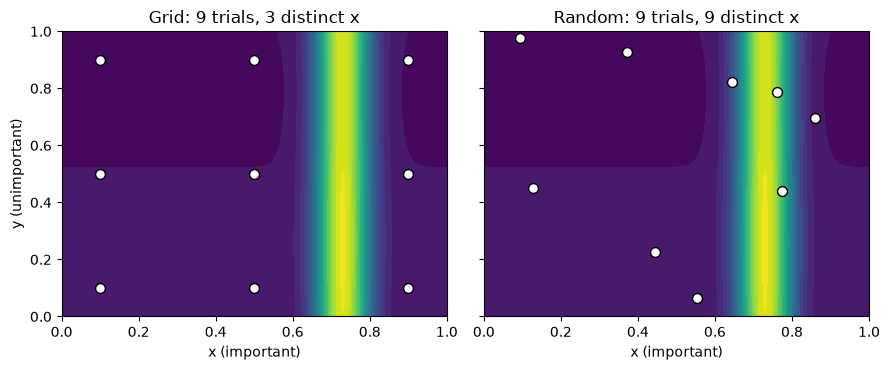

best score, 3×3 grid          : 0.009
best score, 9 random (median of 200 repeats): 0.742 | beats the grid in 99% of repeats


In [4]:
def important_x(x, y):
    """Only x really matters (a sharp peak near x=0.73); y changes the score by at most 1%."""
    return np.exp(-((x - 0.73) ** 2) / 0.005) + 0.01 * np.sin(6 * y)


grid_pts = np.array([(x, y) for x in np.linspace(0.1, 0.9, 3) for y in np.linspace(0.1, 0.9, 3)])
rng = np.random.default_rng(SEED)
random_pts = rng.uniform(0, 1, size=(9, 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
for ax, pts, title in [(axes[0], grid_pts, "Grid: 9 trials, 3 distinct x"), (axes[1], random_pts, "Random: 9 trials, 9 distinct x")]:
    ax.contourf(xx, yy, important_x(xx, yy), levels=20, cmap="viridis")
    ax.scatter(pts[:, 0], pts[:, 1], c="white", edgecolor="black", s=50)
    ax.set(title=title, xlabel="x (important)")
axes[0].set_ylabel("y (unimportant)")
plt.tight_layout()
plt.show()

grid_best, random_best = [], []
for seed in range(200):
    r = np.random.default_rng(seed).uniform(0, 1, size=(9, 2))
    random_best.append(important_x(r[:, 0], r[:, 1]).max())
grid_best = important_x(grid_pts[:, 0], grid_pts[:, 1]).max()
print(f"best score, 3×3 grid          : {grid_best:.3f}")
print(f"best score, 9 random (median of 200 repeats): {np.median(random_best):.3f} | beats the grid in {np.mean(np.array(random_best) > grid_best):.0%} of repeats")

**Bayesian optimization** goes further: it uses the results so far to decide where to look next. Optuna's default, **TPE (Tree-structured Parzen Estimator)**, splits past trials into a *good* group and a *bad* group and samples where good trials are dense and bad ones are rare (we build it from scratch later).

Below: 40 trials on the classic **Branin** test function (three equally good minima). Random search spreads trials everywhere; TPE concentrates them in the valleys.

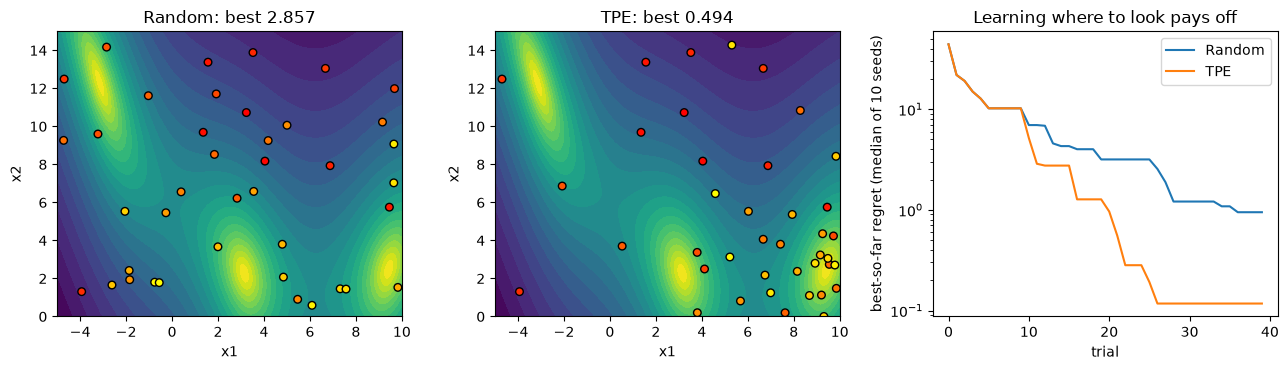

median regret after 40 trials — Random: 0.947 | TPE: 0.117 → TPE is 8× closer to the true minimum


In [5]:
def branin(x1, x2):
    a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)
    return a * (x2 - b * x1 ** 2 + c * x1 - r) ** 2 + s * (1 - t) * np.cos(x1) + s


BRANIN_MIN = 0.397887


def branin_objective(trial):
    return float(branin(trial.suggest_float("x1", -5, 10), trial.suggest_float("x2", 0, 15)))


demo = {}
for name, sampler in [("Random", optuna.samplers.RandomSampler(seed=0)), ("TPE", optuna.samplers.TPESampler(seed=0))]:
    demo[name] = optuna.create_study(sampler=sampler)
    demo[name].optimize(branin_objective, n_trials=40)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
g1, g2 = np.meshgrid(np.linspace(-5, 10, 200), np.linspace(0, 15, 200))
for ax, name in zip(axes[:2], demo):
    pts = np.array([[t.params["x1"], t.params["x2"]] for t in demo[name].trials])
    ax.contourf(g1, g2, np.log1p(branin(g1, g2)), levels=25, cmap="viridis_r")
    ax.scatter(pts[:, 0], pts[:, 1], c=np.arange(len(pts)), cmap="autumn", edgecolor="black", s=30)
    ax.set(title=f"{name}: best {demo[name].best_value:.3f}", xlabel="x1", ylabel="x2")

curves = {"Random": [], "TPE": []}
for seed in range(10):
    for name, make in [("Random", optuna.samplers.RandomSampler), ("TPE", optuna.samplers.TPESampler)]:
        st = optuna.create_study(sampler=make(seed=seed))
        st.optimize(branin_objective, n_trials=40)
        curves[name].append(np.minimum.accumulate([t.value for t in st.trials]) - BRANIN_MIN)
for name, runs in curves.items():
    axes[2].plot(np.median(runs, axis=0), label=name)
axes[2].set(yscale="log", xlabel="trial", ylabel="best-so-far regret (median of 10 seeds)", title="Learning where to look pays off")
axes[2].legend()
plt.tight_layout()
plt.show()

final_regret = {name: float(np.median([r[-1] for r in runs])) for name, runs in curves.items()}
print(f"median regret after 40 trials — Random: {final_regret['Random']:.3f} | TPE: {final_regret['TPE']:.3f} "
      f"→ TPE is {final_regret['Random'] / final_regret['TPE']:.0f}× closer to the true minimum")

> 💡 **Interview angle:** "Why is random search usually better than grid search?" — with the same budget, random search tries many more distinct values of each hyperparameter, and only a few hyperparameters usually matter. Bayesian methods (TPE, Gaussian processes) improve further by using past results, which matters most when each trial is expensive.

## 3. Your First Study: the Objective Function 🟢

Three steps:

1. **Objective:** a function that receives a `trial`, asks it for hyperparameters with `trial.suggest_*`, and returns a number.
2. **Study:** `optuna.create_study(direction="minimize" | "maximize")` — the direction must match what you return.
3. **Optimize:** `study.optimize(objective, n_trials=...)`.

In [6]:
def toy_objective(trial):
    x = trial.suggest_float("x", -10, 10)
    return (x - 2) ** 2                                     # a loss → minimize


toy = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
toy.optimize(toy_objective, n_trials=30)
print(f"best x = {toy.best_params['x']:.3f} (true optimum 2) | best value = {toy.best_value:.4f} | trials run: {len(toy.trials)}")
print(toy.trials_dataframe(attrs=("number", "value", "params", "state")).head())

best x = 2.005 (true optimum 2) | best value = 0.0000 | trials run: 30
   number      value  params_x     state
0       0  20.332863 -2.509198  COMPLETE
1       1  49.200210  9.014286  COMPLETE
2       2   6.968960  4.639879  COMPLETE
3       3   0.000720  1.973170  COMPLETE
4       4  78.847779 -6.879627  COMPLETE


Now a real objective: LightGBM on Adult, scored by **validation ROC-AUC** (higher is better → `direction="maximize"`). Early stopping on the validation set picks the number of trees, and we store it on the trial with `set_user_attr` so we can reuse it later.

In [7]:
def lgbm_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 128, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    model = lgb.LGBMClassifier(n_estimators=1000, verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED, **params)
    model.fit(X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False)])
    trial.set_user_attr("best_iteration", int(model.best_iteration_))
    return model.best_score_["valid_0"]["auc"]              # AUC: higher is better → maximize


first_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
start = time.perf_counter()
first_study.optimize(lgbm_objective, n_trials=15)
print(f"15 trials in {time.perf_counter() - start:.1f}s | best validation AUC {first_study.best_value:.4f} "
      f"(defaults scored {config_scores['LightGBM defaults']:.4f})")
print("best params:", {k: round(v, 4) if isinstance(v, float) else v for k, v in first_study.best_params.items()},
      "| trees:", first_study.best_trial.user_attrs["best_iteration"])

15 trials in 10.3s | best validation AUC 0.9320 (defaults scored 0.9302)
best params: {'learning_rate': 0.204, 'num_leaves': 14, 'min_child_samples': 8, 'colsample_bytree': 0.5917} | trees: 93


### ✍️ Your Turn

An objective returns **log-loss** (lower is better). Which `direction` must its study use? Store the string in `logloss_direction`.

In [8]:
logloss_direction = None  # TODO: "minimize" or "maximize"
check("logloss_direction", logloss_direction, "minimize", hint="Do you want log-loss to go up or down?")

⏳ logloss_direction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logloss_direction = "minimize"
check("logloss_direction", logloss_direction, "minimize")
```

Return the metric as-is and set the matching direction. Don't negate AUC "to minimize it" *and* set `direction="maximize"` — that optimizes for the worst model (Pitfall 1 shows it).
</details>

> 💡 **Interview angle:** "What does an Optuna objective look like?" — sample hyperparameters with `trial.suggest_*`, train and evaluate on validation data (or CV), return the metric, and match `direction`. Optuna is *define-by-run*: the search space is whatever your Python code asks for, so loops and `if` statements just work.

## 4. Search Spaces: Log Scales, Categories and Conditional Parameters 🟡

| Call | Samples | Use for |
|---|---|---|
| `suggest_float(name, low, high)` | uniform float | fractions like `colsample_bytree` |
| `suggest_float(name, low, high, log=True)` | uniform in **log space** | learning rates, regularization strengths (span decades) |
| `suggest_float(name, low, high, step=0.1)` | discretized float | coarse knobs |
| `suggest_int(name, low, high[, step][, log=True])` | integer | `num_leaves`, `max_depth`, layer sizes |
| `suggest_categorical(name, choices)` | one of the choices | booster type, optimizer, activation |

**Log scale matters.** For a learning rate between 0.0001 and 0.1, each decade (0.0001–0.001, 0.001–0.01, 0.01–0.1) deserves equal attention. On a linear scale, 90% of samples land in the top decade.

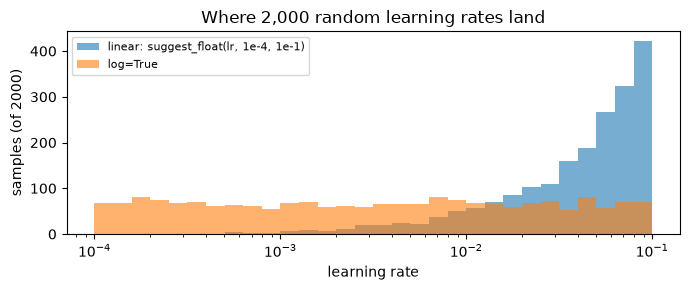

linear: share below 0.001 = 0.5% | below 0.01 = 10.7%
log   : share below 0.001 = 33.5% | below 0.01 = 66.8%


In [9]:
def lr_samples(log, n=2000):
    st = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=SEED))
    st.optimize(lambda t: t.suggest_float("lr", 1e-4, 1e-1, log=log), n_trials=n)
    return np.array([t.params["lr"] for t in st.trials])


linear_lr, log_lr = lr_samples(False), lr_samples(True)
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(-4, -1, 31)
ax.hist(linear_lr, bins=bins, alpha=0.6, label="linear: suggest_float(lr, 1e-4, 1e-1)")
ax.hist(log_lr, bins=bins, alpha=0.6, label="log=True")
ax.set(xscale="log", xlabel="learning rate", ylabel="samples (of 2000)", title="Where 2,000 random learning rates land")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, s in [("linear", linear_lr), ("log", log_lr)]:
    print(f"{name:6s}: share below 0.001 = {np.mean(s < 1e-3):.1%} | below 0.01 = {np.mean(s < 1e-2):.1%}")

**Conditional (hierarchical) spaces**: some hyperparameters only exist for some choices. Because Optuna is define-by-run, you just write an `if`. Here the study chooses between logistic regression (tuning `C`) and LightGBM (tuning `num_leaves` and `learning_rate`) on a 10,000-row subsample:

In [10]:
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=10_000, stratify=y_train, random_state=SEED)
cat_cols = X_train.select_dtypes("category").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]


def conditional_objective(trial):
    family = trial.suggest_categorical("family", ["logistic_regression", "lightgbm"])
    if family == "logistic_regression":
        C = trial.suggest_float("C", 1e-3, 1e2, log=True)
        model = make_pipeline(
            make_column_transformer((OneHotEncoder(handle_unknown="ignore"), cat_cols), (StandardScaler(), num_cols)),
            LogisticRegression(C=C, max_iter=2000))
    else:
        model = lgb.LGBMClassifier(num_leaves=trial.suggest_int("num_leaves", 4, 64, log=True),
                                   learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
                                   n_estimators=200, verbose=-1, n_jobs=1, random_state=SEED)
    model.fit(X_sub, y_sub)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])


cond_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
start = time.perf_counter()
cond_study.optimize(conditional_objective, n_trials=24)
cond_df = cond_study.trials_dataframe(attrs=("number", "value", "params"))
print(f"24 trials in {time.perf_counter() - start:.1f}s")
print(cond_df.sort_values("value", ascending=False).head(6).round(4).to_string(index=False))
best_by_family = cond_df.groupby("params_family")["value"].agg(["count", "max"])
print("\n", best_by_family.round(4))

24 trials in 3.0s
 number  value  params_C params_family  params_learning_rate  params_num_leaves
     18 0.9247       NaN      lightgbm                0.0542               18.0
     16 0.9245       NaN      lightgbm                0.0442               17.0
      4 0.9243       NaN      lightgbm                0.0828                8.0
     10 0.9242       NaN      lightgbm                0.2762                4.0
     19 0.9240       NaN      lightgbm                0.0427               19.0
     17 0.9240       NaN      lightgbm                0.0500               20.0

                      count     max
params_family                     
lightgbm                18  0.9247
logistic_regression      6  0.9068


Notice the `NaN`s: `C` doesn't exist in LightGBM trials, and `num_leaves` doesn't exist in logistic-regression trials. TPE handles these conditional spaces natively.

### ✍️ Your Turn

Write `dart_space(trial)`: it suggests `boosting_type` from `["gbdt", "dart"]`, always suggests `learning_rate` (0.01–0.3, log scale), and **only for `"dart"`** also suggests `drop_rate` (0.05–0.5). Return a dict of the suggested values. The check runs 40 random trials and verifies that `drop_rate` appears **exactly** in the dart trials.

In [11]:
# helper for the check below: runs 40 random trials of your space and inspects which parameters appeared
def _dart_check(space):
    if space(optuna.trial.FixedTrial({"boosting_type": "gbdt", "learning_rate": 0.1, "drop_rate": 0.1})) is None:
        return None
    st = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=0))
    st.optimize(lambda t: (space(t), 0.0)[1], n_trials=40)
    return all(("drop_rate" in t.params) == (t.params["boosting_type"] == "dart") and "learning_rate" in t.params for t in st.trials)

In [12]:
def dart_space(trial):
    return None  # TODO: suggest values and return them in a dict


check("dart_space", _dart_check(dart_space), True, hint="if boosting_type == 'dart': params['drop_rate'] = trial.suggest_float(...)")

⏳ dart_space: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def dart_space(trial):
    params = {"boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "dart"]),
              "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)}
    if params["boosting_type"] == "dart":
        params["drop_rate"] = trial.suggest_float("drop_rate", 0.05, 0.5)
    return params

check("dart_space", _dart_check(dart_space), True)
```

`optuna.trial.FixedTrial` lets you call an objective or space function with fixed values — handy for unit tests.
</details>

> 💡 **Interview angle:** "How do you set up a search space?" — use log scales for anything spanning orders of magnitude (learning rate, L2, C), keep ranges wide enough to include the defaults, express conditional parameters with `if`, and after a first study narrow ranges where the good trials cluster instead of guessing up front.

## 5. Samplers and Reproducibility 🟡

The **sampler** decides which hyperparameters the next trial gets.

| Sampler | Idea | Good for |
|---|---|---|
| `TPESampler` (default) | model densities of good vs bad trials; sample where good/bad is high | general-purpose, conditional and categorical spaces |
| `RandomSampler` | independent uniform draws | baselines, huge parallel budgets, the first trials |
| `GPSampler` | Gaussian-process Bayesian optimization | small budgets of expensive, continuous trials |
| `CmaEsSampler` | evolution strategy that adapts a search distribution | continuous spaces with hundreds+ of trials (needs the `cmaes` package) |
| `GridSampler` | every combination of a given grid, then stops | small exhaustive sweeps, reproducing papers |
| `NSGAIISampler` | genetic algorithm | multi-objective studies |

In Optuna 5.0, `TPESampler()` starts with `n_startup_trials=10` random trials, uses **multivariate** TPE for single-objective studies by default (it models parameters jointly), and has `constant_liar=True` so parallel workers don't all pick the same point. Let's race the samplers on Branin, 5 seeds × 40 trials each.

**One environment quirk, handled honestly:** `GPSampler` uses PyTorch. On this macOS laptop, loading PyTorch into a process that has already run LightGBM crashes the Python process (both ship their own OpenMP runtime). So the GP runs happen in a **separate Python process**, and its results come back as JSON. On Linux/Colab you can call `GPSampler` directly.

In [13]:
import importlib.util
import json

sampler_factories = {
    "Random": lambda s: optuna.samplers.RandomSampler(seed=s),
    "TPE": lambda s: optuna.samplers.TPESampler(seed=s),
}
if importlib.util.find_spec("cmaes") is not None:
    sampler_factories["CMA-ES"] = lambda s: optuna.samplers.CmaEsSampler(seed=s)
else:
    print("⏭️ Skipped CMA-ES: it needs the optional `cmaes` package (pip install cmaes).")

race = {}
for name, make in sampler_factories.items():
    start = time.perf_counter()
    regrets = []
    for seed in range(5):
        st = optuna.create_study(sampler=make(seed))
        st.optimize(branin_objective, n_trials=40)
        regrets.append(st.best_value - BRANIN_MIN)
    race[name] = (float(np.median(regrets)), time.perf_counter() - start)

GP_RACE = """
import json, numpy as np, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
def branin(x1, x2):
    a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)
    return a * (x2 - b * x1 ** 2 + c * x1 - r) ** 2 + s * (1 - t) * np.cos(x1) + s
regrets = []
for seed in range(5):
    st = optuna.create_study(sampler=optuna.samplers.GPSampler(seed=seed))
    st.optimize(lambda t: float(branin(t.suggest_float("x1", -5, 10), t.suggest_float("x2", 0, 15))), n_trials=40)
    regrets.append(st.best_value - 0.397887)
print(json.dumps(regrets))
"""
start = time.perf_counter()
gp_run = subprocess.run([sys.executable, "-c", GP_RACE], capture_output=True, text=True, timeout=600)
if gp_run.returncode == 0:
    race["GP"] = (float(np.median(json.loads(gp_run.stdout.strip().splitlines()[-1]))), time.perf_counter() - start)
else:
    print("⏭️ Skipped GP: the GPSampler subprocess failed —", gp_run.stderr.strip().splitlines()[-1][:120] if gp_run.stderr.strip() else f"exit code {gp_run.returncode}")

grid_values = np.linspace(-5, 10, 7).tolist(), np.linspace(0, 15, 6).tolist()     # 42 grid points ≈ same budget
grid_study = optuna.create_study(sampler=optuna.samplers.GridSampler({"x1": grid_values[0], "x2": grid_values[1]}, seed=0))
grid_study.optimize(branin_objective, n_trials=100)                                  # stops by itself when the grid is exhausted
race["Grid (7×6)"] = (grid_study.best_value - BRANIN_MIN, float("nan"))

for name, (regret, seconds) in sorted(race.items(), key=lambda kv: kv[1][0]):
    print(f"{name:11s} median regret {regret:8.4f}" + (f" | {seconds:4.1f}s for 5 studies" if not math.isnan(seconds) else f" | ran {len(grid_study.trials)} trials, then stopped"))

⏭️ Skipped CMA-ES: it needs the optional `cmaes` package (pip install cmaes).


GP          median regret   0.0000 |  2.6s for 5 studies
TPE         median regret   0.0713 |  0.1s for 5 studies
Random      median regret   1.0566 |  0.0s for 5 studies
Grid (7×6)  median regret   1.5453 | ran 42 trials, then stopped


**Reproducibility.** Seed the sampler and run trials **sequentially** to get exactly the same trials again. With `n_jobs > 1` the order in which trials finish (and so what the sampler has seen) depends on thread timing, so results differ even with a seed.

In [14]:
def quadratic_2d(trial):
    return (trial.suggest_float("x", -5, 5) - 1) ** 2 + trial.suggest_float("y", -5, 5) ** 2


def trial_xs(seed, n_jobs):
    st = optuna.create_study(sampler=optuna.samplers.TPESampler(seed=seed))
    st.optimize(quadratic_2d, n_trials=30, n_jobs=n_jobs)
    return [round(t.params["x"], 8) for t in sorted(st.trials, key=lambda t: t.number)]


print("same seed, n_jobs=1 → identical trials:", trial_xs(7, 1) == trial_xs(7, 1))
print("same seed, n_jobs=4 → identical trials:", trial_xs(7, 4) == trial_xs(7, 4))
print("different seeds     → identical trials:", trial_xs(7, 1) == trial_xs(8, 1))

same seed, n_jobs=1 → identical trials: True
same seed, n_jobs=4 → identical trials: False
different seeds     → identical trials: False


> 💡 **Interview angle:** "Which sampler would you use?" — TPE by default (handles categorical and conditional spaces, cheap); GP-based BO for a small number of expensive continuous trials; CMA-ES for long continuous runs; random search as a baseline and for massive parallelism; NSGA-II or multi-objective TPE for trade-offs. For reproducibility, seed the sampler and run sequentially.

## 6. Pruning: Stop Bad Trials Early 🟡

Training is often **iterative** (boosting rounds, epochs). Report an intermediate score as you go; the **pruner** compares it with other trials at the same step and raises `TrialPruned` if the trial looks hopeless.

```python
for step in ...:
    score = evaluate()
    trial.report(score, step)
    if trial.should_prune():
        raise optuna.TrialPruned()
```

- **`MedianPruner`** — prune if the trial's best intermediate value so far is worse than the **median** of other trials at the same step. **It is the default pruner** when you call `create_study()` without one (verified below). Its knobs: `n_startup_trials=5` (don't prune until 5 trials finished), `n_warmup_steps=0` (don't prune before this step), `interval_steps=1`.
- **`HyperbandPruner`** — runs several *successive halving* brackets: many trials get a small budget, the best fraction (1/`reduction_factor`) continue to larger budgets.
- **`NopPruner`** — never prunes. Useful as a control.

Pruning only acts when the objective calls `report()` + `should_prune()`. Without them, the default MedianPruner does nothing.

In [15]:
print("default pruner:", type(optuna.create_study().pruner).__name__, "| default sampler:", type(optuna.create_study().sampler).__name__)

REPORT_EVERY = 25


def pruned_lgbm_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 128, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }

    def report_and_maybe_prune(env):                       # a LightGBM callback, called after every boosting round
        step = env.iteration + 1
        if step % REPORT_EVERY == 0:
            auc = next(value for _, metric, value, _ in env.evaluation_result_list if metric == "auc")
            trial.report(auc, step)
            if trial.should_prune():
                raise optuna.TrialPruned(f"pruned at round {step}")

    model = lgb.LGBMClassifier(n_estimators=600, verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED, **params)
    model.fit(X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric="auc",
              callbacks=[report_and_maybe_prune, lgb.early_stopping(50, verbose=False)])
    trial.set_user_attr("best_iteration", int(model.best_iteration_))
    return model.best_score_["valid_0"]["auc"]


pruner_results = {}
pruning_studies = {}
for name, pruner in [("NopPruner", optuna.pruners.NopPruner()),
                     ("MedianPruner", optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=REPORT_EVERY)),
                     ("HyperbandPruner", optuna.pruners.HyperbandPruner(min_resource=REPORT_EVERY, max_resource=600, reduction_factor=3))]:
    st = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED), pruner=pruner)
    start = time.perf_counter()
    st.optimize(pruned_lgbm_objective, n_trials=20)
    pruning_studies[name] = st
    n_pruned = sum(t.state == TrialState.PRUNED for t in st.trials)
    pruner_results[name] = dict(seconds=time.perf_counter() - start, pruned=n_pruned, best_auc=st.best_value)

pruner_table = pd.DataFrame(pruner_results).T
print(pruner_table.assign(seconds=lambda d: d.seconds.astype(float).round(1), best_auc=lambda d: d.best_auc.astype(float).round(4)))
saved = 1 - pruner_results["MedianPruner"]["seconds"] / pruner_results["NopPruner"]["seconds"]
auc_cost = pruner_results["NopPruner"]["best_auc"] - pruner_results["MedianPruner"]["best_auc"]
print(f"→ MedianPruner saved {saved:.0%} of the time; best AUC " + ("unchanged (to 4 decimals)" if abs(auc_cost) < 5e-5 else f"changed by {-auc_cost:+.4f}"))

default pruner: MedianPruner | default sampler: TPESampler


                 seconds  pruned  best_auc
NopPruner           15.4     0.0     0.932
MedianPruner        11.0    13.0     0.932
HyperbandPruner      9.0    12.0     0.932
→ MedianPruner saved 29% of the time; best AUC unchanged (to 4 decimals)


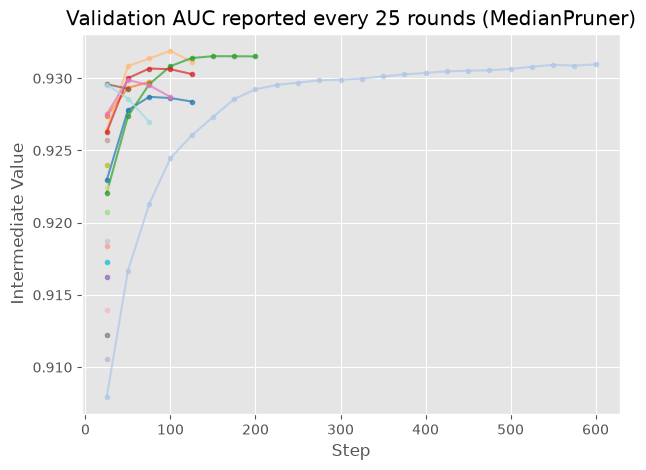

In [16]:
optuna_plt.plot_intermediate_values(pruning_studies["MedianPruner"])
plt.title("Validation AUC reported every 25 rounds (MedianPruner)")
plt.gca().get_legend().remove() if plt.gca().get_legend() else None
plt.tight_layout()
plt.show()

Curves that stop early are pruned trials. Early stopping and pruning are different: **early stopping** ends *one* model once *its own* validation score stops improving; **pruning** ends a trial because it is worse than *other trials* at the same point.

### ✍️ Your Turn

From the `MedianPruner` study, compute `(n_pruned, n_complete)` — the number of trials in each state — as a tuple of two integers.

In [17]:
median_study = pruning_studies["MedianPruner"]
pruned_complete = None  # TODO: (number of PRUNED trials, number of COMPLETE trials)
check("pruned_complete", pruned_complete,
      (sum(t.state == TrialState.PRUNED for t in median_study.trials), sum(t.state == TrialState.COMPLETE for t in median_study.trials)),
      hint="t.state == TrialState.PRUNED — or median_study.get_trials(states=(TrialState.PRUNED,))")

⏳ pruned_complete: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
median_study = pruning_studies["MedianPruner"]
pruned_complete = (len(median_study.get_trials(states=(TrialState.PRUNED,))),
                   len(median_study.get_trials(states=(TrialState.COMPLETE,))))
check("pruned_complete", pruned_complete,
      (sum(t.state == TrialState.PRUNED for t in median_study.trials), sum(t.state == TrialState.COMPLETE for t in median_study.trials)))
```
</details>

> 💡 **Interview angle:** "How does Hyperband work?" — it runs successive halving with several trade-offs between *how many* configurations to try and *how much* budget each gets: give many trials a small budget, keep the top 1/η, multiply their budget by η, repeat. It hedges against not knowing whether early scores predict final scores. ASHA is its asynchronous, parallel-friendly version.

## 7. Storage, Resuming and Parallel Trials 🟡

By default a study lives in memory and disappears with the Python process. Give it a **storage** URL and every trial is saved as it finishes, so you can **resume** after a crash, inspect results in another process (or `optuna-dashboard`), and let several workers share one study.

- `storage="sqlite:///_outputs/optuna/studies.db"` — a single-file database (a relative path, resolved from the notebook's folder).
- `load_if_exists=True` — continue the study with this name if it already exists.
- For several **processes** on one machine, Optuna recommends `JournalStorage(JournalFileBackend(path))`. For many machines, use a server database (PostgreSQL/MySQL).

In [18]:
STORAGE = f"sqlite:///{(OPTUNA_DIR / 'studies.db').as_posix()}"
print("storage URL:", STORAGE)
for name in optuna.get_all_study_names(STORAGE) if (OPTUNA_DIR / "studies.db").exists() else []:
    optuna.delete_study(study_name=name, storage=STORAGE)        # start fresh each time the notebook runs

session_1 = optuna.create_study(study_name="branin-resume", storage=STORAGE, direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED), load_if_exists=True)
session_1.optimize(branin_objective, n_trials=15)
print(f"session 1: {len(session_1.trials)} trials, best {session_1.best_value:.4f}")
del session_1                                                    # pretend the kernel crashed

session_2 = optuna.load_study(study_name="branin-resume", storage=STORAGE, sampler=optuna.samplers.TPESampler(seed=SEED + 1))
session_2.optimize(branin_objective, n_trials=15)
print(f"session 2: {len(session_2.trials)} trials (numbers {session_2.trials[0].number}…{session_2.trials[-1].number}), best {session_2.best_value:.4f}")
print("studies in the database:", optuna.get_all_study_names(STORAGE))

storage URL: sqlite:///_outputs/optuna/studies.db


session 1: 15 trials, best 2.4646
session 2: 30 trials (numbers 0…29), best 0.6042
studies in the database: ['branin-resume']


**Parallel trials.** `study.optimize(..., n_jobs=k)` runs `k` trials at once in **threads** of one process. That helps when the objective releases Python's GIL (LightGBM, XGBoost, PyTorch, remote calls) or waits on I/O. For pure-Python objectives, run several **processes** that share one storage. Below, two separate Python processes each run 10 trials of the same study.

In [19]:
def slow_io_objective(trial):
    time.sleep(0.2)                                              # stands in for waiting on a GPU job or a remote service
    return trial.suggest_float("x", 0, 1)


for n_jobs in (1, 4):
    st = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=0))
    start = time.perf_counter()
    st.optimize(slow_io_objective, n_trials=12, n_jobs=n_jobs)
    print(f"n_jobs={n_jobs}: 12 trials × 0.2 s wait → {time.perf_counter() - start:.2f}s")

n_jobs=1: 12 trials × 0.2 s wait → 2.44s


n_jobs=4: 12 trials × 0.2 s wait → 0.61s


In [20]:
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend

JOURNAL = OPTUNA_DIR / "shared_study.log"
JOURNAL.unlink(missing_ok=True)
optuna.create_study(study_name="shared", storage=JournalStorage(JournalFileBackend(str(JOURNAL))), direction="minimize")

WORKER_CODE = """
import sys, optuna
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.load_study(study_name="shared", storage=JournalStorage(JournalFileBackend(sys.argv[2])))
def objective(trial):
    trial.set_user_attr("worker", int(sys.argv[1]))
    return (trial.suggest_float("x", -5, 5) - 1) ** 2 + trial.suggest_float("y", -5, 5) ** 2
study.optimize(objective, n_trials=10)
"""
start = time.perf_counter()
workers = [subprocess.Popen([sys.executable, "-c", WORKER_CODE, str(w), str(JOURNAL)]) for w in range(2)]
exit_codes = [w.wait() for w in workers]
shared = optuna.load_study(study_name="shared", storage=JournalStorage(JournalFileBackend(str(JOURNAL))))
per_worker = pd.Series([t.user_attrs["worker"] for t in shared.trials]).value_counts().sort_index().to_dict()
print(f"exit codes {exit_codes} | {len(shared.trials)} trials in {time.perf_counter() - start:.1f}s | trials per worker {per_worker} | "
      f"unique trial numbers: {len({t.number for t in shared.trials})} | best {shared.best_value:.4f}")

exit codes [0, 0] | 20 trials in 0.2s | trials per worker {0: 10, 1: 10} | unique trial numbers: 20 | best 0.2273


> 💡 **Interview angle:** "How do you run a hyperparameter search on 20 GPUs?" — one shared storage (a database or journal), 20 workers each calling `load_study(...).optimize(...)`, a sampler that tolerates parallelism (TPE with `constant_liar`, or random), and an asynchronous pruner (ASHA/Hyperband-style) so slow trials don't block. Save every trial so crashes lose nothing.

## 8. Multi-Objective Optimization and the Pareto Front 🔴

Real systems care about more than one number: accuracy **and** latency, AUC **and** model size, quality **and** cost. Usually there is no single best trial, only a set of **Pareto-optimal** trials: nobody else is better on one objective without being worse on another. That set is the **Pareto front**.

Pass `directions=[...]` and return a tuple. We maximize validation AUC and minimize **model size** (total number of leaves across all trees — a proxy for memory and prediction latency).

In [21]:
def auc_and_size_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 4, 128, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 20, 400, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
    }
    model = lgb.LGBMClassifier(verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED, **params).fit(X_train, y_train)
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    total_leaves = sum(tree["num_leaves"] for tree in model.booster_.dump_model()["tree_info"])
    return auc, total_leaves


mo_study = optuna.create_study(directions=["maximize", "minimize"], sampler=optuna.samplers.TPESampler(seed=SEED))
start = time.perf_counter()
mo_study.optimize(auc_and_size_objective, n_trials=40)
pareto = sorted(mo_study.best_trials, key=lambda t: t.values[1])
print(f"40 trials in {time.perf_counter() - start:.1f}s | Pareto-optimal trials: {len(pareto)}")
for t in pareto:
    print(f"  trial {t.number:2d}: AUC {t.values[0]:.4f} | total leaves {int(t.values[1]):6,d} | {t.params}")

40 trials in 9.5s | Pareto-optimal trials: 7
  trial 16: AUC 0.9131 | total leaves    104 | {'learning_rate': 0.17743744166911146, 'num_leaves': 4, 'n_estimators': 26, 'min_child_samples': 68}
  trial 39: AUC 0.9174 | total leaves    110 | {'learning_rate': 0.26897937858775417, 'num_leaves': 5, 'n_estimators': 22, 'min_child_samples': 81}
  trial 33: AUC 0.9235 | total leaves    168 | {'learning_rate': 0.25314384000779, 'num_leaves': 7, 'n_estimators': 24, 'min_child_samples': 6}
  trial 37: AUC 0.9257 | total leaves    225 | {'learning_rate': 0.26476718117429543, 'num_leaves': 9, 'n_estimators': 25, 'min_child_samples': 98}
  trial 26: AUC 0.9284 | total leaves    336 | {'learning_rate': 0.29199002991726414, 'num_leaves': 12, 'n_estimators': 28, 'min_child_samples': 71}
  trial 25: AUC 0.9292 | total leaves    638 | {'learning_rate': 0.2946624478071172, 'num_leaves': 11, 'n_estimators': 58, 'min_child_samples': 72}
  trial 31: AUC 0.9293 | total leaves    672 | {'learning_rate': 0.296

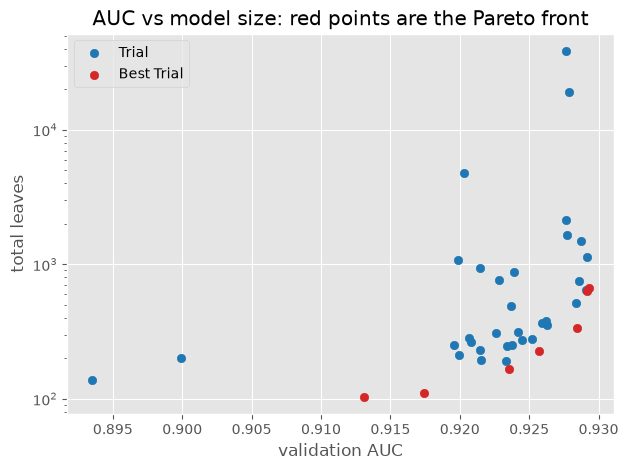

most accurate: trial 31 (AUC 0.9293, 672 leaves)
smallest within 0.002 AUC of it: trial 26 (AUC 0.9284, 336 leaves) → 2.0× smaller for 0.0009 AUC


In [22]:
optuna_plt.plot_pareto_front(mo_study, target_names=["validation AUC", "total leaves"])
plt.yscale("log")
plt.title("AUC vs model size: red points are the Pareto front")
plt.tight_layout()
plt.show()

best_auc = max(t.values[0] for t in pareto)
TOLERANCE = 0.002
compact = min((t for t in pareto if t.values[0] >= best_auc - TOLERANCE), key=lambda t: t.values[1])
largest = max(pareto, key=lambda t: t.values[0])
print(f"most accurate: trial {largest.number} (AUC {largest.values[0]:.4f}, {int(largest.values[1]):,} leaves)")
print(f"smallest within {TOLERANCE} AUC of it: trial {compact.number} (AUC {compact.values[0]:.4f}, {int(compact.values[1]):,} leaves) "
      f"→ {largest.values[1] / compact.values[1]:.1f}× smaller for {largest.values[0] - compact.values[0]:.4f} AUC")

`study.best_trial` raises an error for multi-objective studies (there is no single best). Use `study.best_trials` and a **business rule** to choose, like "smallest model within 0.002 AUC of the best".

> 💡 **Interview angle:** "How would you tune a model for both accuracy and latency?" — either a multi-objective search that returns the Pareto front and then a stated selection rule, or a constrained single objective (maximize accuracy subject to p95 latency ≤ budget). Measure latency on the serving hardware and batch size, not on your laptop.

## 9. Visualizing a Study 🟢

`optuna.visualization.matplotlib` draws static Matplotlib figures (they render on GitHub; the `optuna.visualization` Plotly versions are interactive). The most useful ones:

| Plot | Answers |
|---|---|
| `plot_optimization_history` | Is the search still improving, or has it plateaued? |
| `plot_param_importances` | Which hyperparameters actually moved the score? (default evaluator in Optuna 5: PED-ANOVA) |
| `plot_slice` | For each hyperparameter, where did the good trials land? Should a range be widened? |
| `plot_contour` | How do two hyperparameters interact? |
| `plot_intermediate_values` | What did pruning cut, and when? (Section 6) |

We visualize the NopPruner LightGBM study from Section 6 (all 20 trials completed).

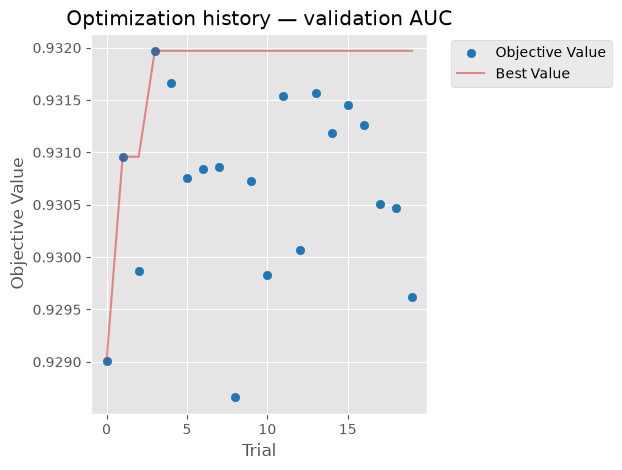

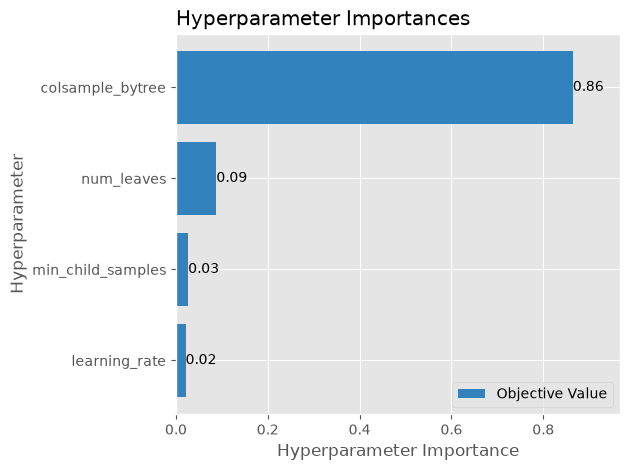

importances: {'colsample_bytree': 0.864, 'num_leaves': 0.088, 'min_child_samples': 0.027, 'learning_rate': 0.021}


In [23]:
viz_study = pruning_studies["NopPruner"]

optuna_plt.plot_optimization_history(viz_study)
plt.title("Optimization history — validation AUC")
plt.tight_layout()
plt.show()

importances = optuna.importance.get_param_importances(viz_study)
optuna_plt.plot_param_importances(viz_study)
plt.tight_layout()
plt.show()
print("importances:", {k: round(v, 3) for k, v in importances.items()})

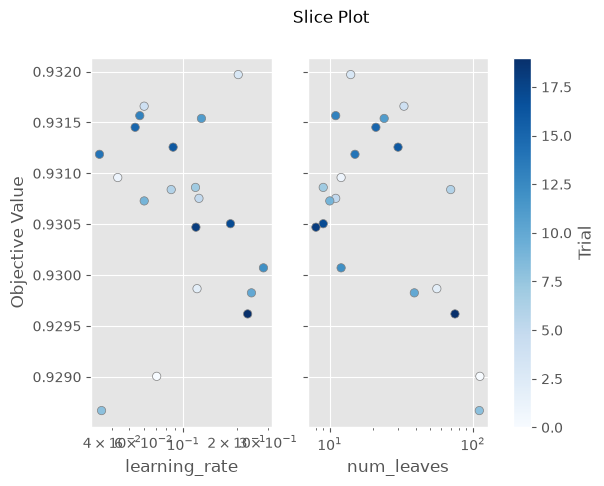

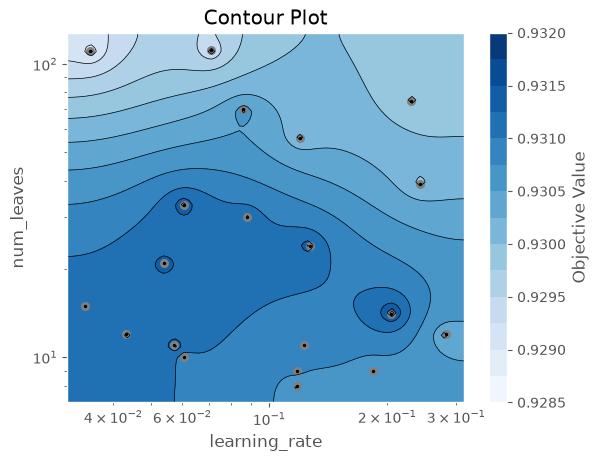

most important: colsample_bytree | top-5 trials used 0.5155–0.6456 (search range 0.5–1.0)
→ the best trials sit at the edge of the range: consider widening it


In [24]:
optuna_plt.plot_slice(viz_study, params=["learning_rate", "num_leaves"])
plt.show()

optuna_plt.plot_contour(viz_study, params=["learning_rate", "num_leaves"])
plt.show()

top_param = next(iter(importances))
good = viz_study.trials_dataframe().nlargest(5, "value")[f"params_{top_param}"]
top_dist = viz_study.best_trial.distributions[top_param]              # each finished trial records the range it was sampled from
low, high = top_dist.low, top_dist.high
print(f"most important: {top_param} | top-5 trials used {good.min():.4g}–{good.max():.4g} (search range {low}–{high})")
edge = good.min() <= low * 1.1 or good.max() >= high * 0.9
print("→ the best trials sit at the edge of the range: consider widening it" if edge else "→ the best trials are inside the range: no need to widen it")

**Reading importances carefully:** they are computed from ~20 trials, describe *this search space*, and can change with more trials. A "useless" parameter may simply have a narrow range. Use them to simplify the next study, not as a law of nature.

> 💡 **Interview angle:** "The study finished — what do you look at?" — the optimization history (plateau → stop or change the space), the slice plots (best values at a range boundary → widen), importances (drop or fix unimportant knobs), and the gap between validation and a fresh holdout (Section 10).

## 10. Tuning Without Leakage — and Overfitting the Validation Set 🔴

Every trial *looks at* the validation data. Pick the best of many noisy scores, and the winner's score is **biased upwards**: part of its lead is luck on those particular validation rows. This is the **winner's curse**, or overfitting the validation set. Rules:

1. Score trials with **cross-validation** (or a large validation set) — never the test set.
2. Keep a **test set** that no tuning decision ever saw, and use it **once**.
3. Expect the final test score to be a bit lower than the best validation score — and worry if the gap is large.

**Demonstration.** A deliberately small setup: 2,000 training rows and a **200-row validation set**. Random search tries 150 LightGBM configurations. For **every** trial we also measure AUC on a **fresh 9,000-row holdout** that tuning never sees (taken from unused training rows; the real test set stays untouched). Then we repeat the search scoring trials with **5-fold CV** on the same 2,200 rows.

Two numbers tell the story:
- **Fresh-data rank of the winner** — the configuration with the best tuning score: is it also among the best on new data?
- **Selection optimism** — the winner's (tuning score − fresh AUC) minus the *average* (tuning score − fresh AUC) over all trials. Subtracting the average cancels the fact that a particular 200-row split may simply be easier or harder than new data; what's left is the extra flattery the winner gets *because it was selected*.

300 trials plus their fresh-data scores in 30.6s


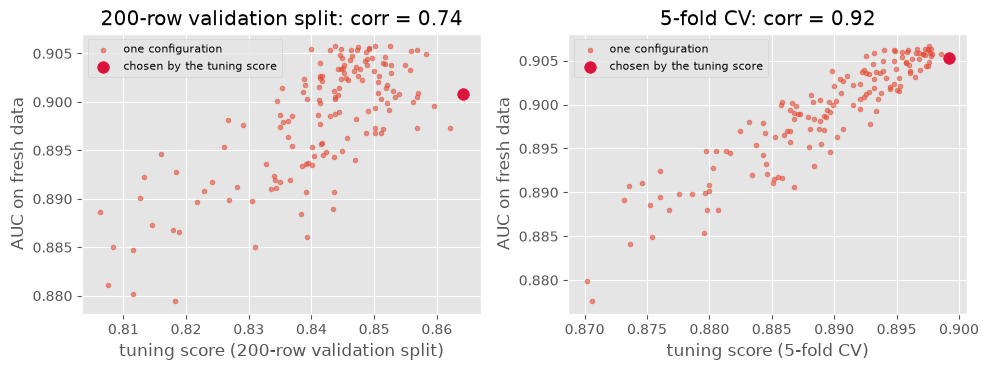

200-row validation split  winner: tuning 0.8642 | fresh 0.9008 (best possible 0.9057) | fresh-data rank 65 of 150 | selection optimism +0.0201
5-fold CV                 winner: tuning 0.8992 | fresh 0.9053 (best possible 0.9066) | fresh-data rank 25 of 150 | selection optimism +0.0037
→ both winners look better at selection time than they are (optimism +0.0201 vs +0.0037)
→ the CV winner generalizes better than the small-split winner


In [25]:
pool_X, fresh_X, pool_y, fresh_y = train_test_split(X_train, y_train, train_size=2_200, stratify=y_train, random_state=1)
fresh_X, fresh_y = fresh_X.iloc[:9_000], fresh_y[:9_000]
small_fit_X, small_val_X, small_fit_y, small_val_y = train_test_split(pool_X, pool_y, test_size=200, stratify=pool_y, random_state=1)
cv_small = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)


def small_params(trial):
    return dict(learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                num_leaves=trial.suggest_int("num_leaves", 4, 64, log=True),
                min_child_samples=trial.suggest_int("min_child_samples", 5, 60, log=True),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                n_estimators=trial.suggest_int("n_estimators", 20, 300, log=True))


def small_model(params):
    return lgb.LGBMClassifier(verbose=-1, n_jobs=1, random_state=0, **params)


def holdout_auc(params, X_fit, y_fit):
    return roc_auc_score(fresh_y, small_model(params).fit(X_fit, y_fit).predict_proba(fresh_X)[:, 1])


def single_split_objective(trial):
    model = small_model(small_params(trial)).fit(small_fit_X, small_fit_y)
    return roc_auc_score(small_val_y, model.predict_proba(small_val_X)[:, 1])


def cv_objective_small(trial):
    params = small_params(trial)
    scores = [roc_auc_score(pool_y[va], small_model(params).fit(pool_X.iloc[tr], pool_y[tr]).predict_proba(pool_X.iloc[va])[:, 1])
              for tr, va in cv_small.split(pool_X, pool_y)]
    return float(np.mean(scores))


N_SMALL = 150
start = time.perf_counter()
selection = {}
for label, objective, fit_X, fit_y in [("200-row validation split", single_split_objective, small_fit_X, small_fit_y),
                                       ("5-fold CV", cv_objective_small, pool_X, pool_y)]:
    st = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=3))
    st.optimize(objective, n_trials=N_SMALL)
    tuning_scores = np.array([t.value for t in st.trials])
    fresh_scores = np.array([holdout_auc(t.params, fit_X, fit_y) for t in st.trials])
    selection[label] = (tuning_scores, fresh_scores)
print(f"{2 * N_SMALL} trials plus their fresh-data scores in {time.perf_counter() - start:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (label, (tuning_scores, fresh_scores)) in zip(axes, selection.items()):
    w = int(tuning_scores.argmax())
    ax.scatter(tuning_scores, fresh_scores, s=12, alpha=0.6, label="one configuration")
    ax.scatter(tuning_scores[w], fresh_scores[w], color="crimson", s=70, label="chosen by the tuning score")
    ax.set(xlabel=f"tuning score ({label})", ylabel="AUC on fresh data",
           title=f"{label}: corr = {np.corrcoef(tuning_scores, fresh_scores)[0, 1]:.2f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

summary_10 = {}
for label, (tuning_scores, fresh_scores) in selection.items():
    w = int(tuning_scores.argmax())
    rank = int((fresh_scores > fresh_scores[w]).sum()) + 1
    optimism = float((tuning_scores[w] - fresh_scores[w]) - np.mean(tuning_scores - fresh_scores))
    summary_10[label] = dict(rank=rank, optimism=optimism, fresh=float(fresh_scores[w]), best_fresh=float(fresh_scores.max()))
    print(f"{label:25s} winner: tuning {tuning_scores[w]:.4f} | fresh {fresh_scores[w]:.4f} (best possible {fresh_scores.max():.4f}) | "
          f"fresh-data rank {rank} of {N_SMALL} | selection optimism {optimism:+.4f}")

split, cv = summary_10["200-row validation split"], summary_10["5-fold CV"]
print(f"→ both winners look better at selection time than they are (optimism {split['optimism']:+.4f} vs {cv['optimism']:+.4f})"
      if split["optimism"] > 0 and cv["optimism"] > 0 else "→ selection optimism was not positive for both methods in this run")
print("→ the CV winner generalizes better than the small-split winner" if cv["fresh"] > split["fresh"]
      else "→ in this run the small-split winner did as well on fresh data — with this little data both estimates are noisy")

**What leakage looks like in code** — and the fix, which the mini project follows:

| ❌ Leaky | ✅ Correct |
|---|---|
| Objective returns the **test** score | Objective returns CV (or validation) score; test is scored once at the end |
| Early stopping uses the test set | Early stopping uses the validation fold inside each CV split |
| Fit a scaler / target encoder on all rows, then CV | Put preprocessing in a pipeline fitted inside each fold |
| "Tune → check test → tweak the space → check test again" | Freeze every decision before touching test |

> 💡 **Interview angle:** "Your tuned model scored 0.95 in validation but 0.91 in production. Why?" — the winner's curse from many trials on a small or reused validation set, leakage into the objective (test data, preprocessing fit on all rows), or distribution shift. Fixes: CV or a larger validation set, nested CV for an unbiased estimate, a single untouched test set, fewer and more meaningful trials, and time-based splits for temporal data.

## 11. From Best Trial to Final Model 🟡

`study.best_params` is a dict of **the names you passed to `suggest_*`** — nothing more. Three things to get right:

1. **Names must map onto real estimator arguments.** If you call `suggest_float("lr", …)`, then `LGBMClassifier(**best_params)` receives `lr=…`, which LightGBM does not know. With `verbose=-1` it is **silently ignored** (Pitfall 2 proves it).
2. **Fixed settings aren't in `best_params`.** Things you didn't tune (`subsample_freq=1`, `random_state`, `n_jobs`) must be added back.
3. **Values chosen during training aren't either.** The number of trees found by early stopping lives in `trial.user_attrs` if you stored it.

The safest pattern: **one function builds the parameters** for both the objective and the final model.

In [26]:
FIXED_PARAMS = dict(subsample_freq=1, verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED)


def build_params(trial_or_params):
    """Works with a live Trial (suggests values) or a finished trial's params dict (reads them) — same names either way."""
    t = trial_or_params if not isinstance(trial_or_params, dict) else optuna.trial.FixedTrial(trial_or_params)
    return {
        "learning_rate": t.suggest_float("learning_rate", 0.03, 0.3, log=True),
        "num_leaves": t.suggest_int("num_leaves", 8, 128, log=True),
        "min_child_samples": t.suggest_int("min_child_samples", 5, 100, log=True),
        "subsample": t.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": t.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        **FIXED_PARAMS,
    }


def mapped_objective(trial):
    model = lgb.LGBMClassifier(n_estimators=1000, **build_params(trial))
    model.fit(X_train, y_train, eval_X=X_val, eval_y=y_val, eval_metric="auc", callbacks=[lgb.early_stopping(50, verbose=False)])
    trial.set_user_attr("n_estimators", int(model.best_iteration_))
    return model.best_score_["valid_0"]["auc"]


mapped_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
mapped_study.optimize(mapped_objective, n_trials=12)

best = mapped_study.best_trial
final_params = build_params(best.params) | {"n_estimators": best.user_attrs["n_estimators"]}
final_model = lgb.LGBMClassifier(**final_params).fit(X_train, y_train)
refit_auc = roc_auc_score(y_val, final_model.predict_proba(X_val)[:, 1])

booster_params = final_model.booster_.params
for key in ("learning_rate", "num_leaves", "subsample", "subsample_freq"):
    assert math.isclose(float(booster_params[key]), float(final_params[key])), key
print("✅ every tuned value reached the LightGBM booster:", {k: booster_params[k] for k in ("learning_rate", "num_leaves", "min_child_samples", "subsample_freq")})
print(f"study's best validation AUC {best.value:.4f} | refit with mapped params + stored n_estimators {refit_auc:.4f}")

✅ every tuned value reached the LightGBM booster: {'learning_rate': 0.12152513343989021, 'num_leaves': 12, 'min_child_samples': 6, 'subsample_freq': 1}
study's best validation AUC 0.9311 | refit with mapped params + stored n_estimators 0.9311


The refit reproduces the trial (same data, same trees), which is a cheap sanity check that nothing was lost in translation. In the mini project we go one step further and **retrain on train + validation** before the single test evaluation.

### ✍️ Your Turn

A colleague's study used the names `"lr"`, `"leaves"` and `"colsample"`. Write `translate(best_params)` that returns a dict with the real LightGBM argument names `learning_rate`, `num_leaves` and `colsample_bytree`.

In [27]:
colleague_best = {"lr": 0.07, "leaves": 48, "colsample": 0.8}


def translate(best_params):
    return None  # TODO


check("translate", translate(colleague_best), {"learning_rate": 0.07, "num_leaves": 48, "colsample_bytree": 0.8},
      hint="A dict comprehension over a {'lr': 'learning_rate', ...} mapping.")

⏳ translate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
colleague_best = {"lr": 0.07, "leaves": 48, "colsample": 0.8}


def translate(best_params):
    names = {"lr": "learning_rate", "leaves": "num_leaves", "colsample": "colsample_bytree"}
    return {names[k]: v for k, v in best_params.items()}


check("translate", translate(colleague_best), {"learning_rate": 0.07, "num_leaves": 48, "colsample_bytree": 0.8})
```

Even better: rename the `suggest_*` calls so no translation is needed, and assert on `model.booster_.params` after fitting.
</details>

> 💡 **Interview angle:** "How do you go from the search to the deployed model?" — rebuild the exact parameter dict (tuned + fixed + early-stopping rounds) from one shared function, retrain on train+validation (scale the tree count a little if the data grew), evaluate once on test, and log the study, parameters and data version together (e.g. MLflow).

## 🔧 Build It From Scratch

### Random search and a simplified TPE

TPE's idea in four steps:

1. Run a few **random** trials to get started.
2. Sort trials by score and split them at a quantile $\gamma$: the best $\gamma$ fraction is **good**, the rest **bad**.
3. Fit two **kernel density estimates** (a Gaussian bump on every point): $l(x)$ on good points, $g(x)$ on bad points.
4. Draw candidates from $l(x)$ and evaluate the one that maximizes $l(x)/g(x)$ — likely under good trials, unlikely under bad ones. (Bergstra et al. show this ratio is equivalent to maximizing Expected Improvement.)

Our version uses a bandwidth that shrinks as points accumulate ($0.1 \cdot \text{range} \cdot n^{-1/(d+4)}$) and adds a wide "prior" Gaussian at the centre of the box so densities never collapse to zero.

In [28]:
def kde_logpdf(x, centers, sigma, low, high):
    """log density of a Gaussian mixture: one bump per center plus a wide prior bump at the middle of the box."""
    all_centers = np.vstack([centers, ((low + high) / 2)[None, :]])
    all_sigmas = np.vstack([np.broadcast_to(sigma, centers.shape), (high - low)[None, :]])
    z = (x[:, None, :] - all_centers[None]) / all_sigmas[None]
    log_k = (-0.5 * z ** 2 - np.log(all_sigmas[None]) - 0.5 * np.log(2 * np.pi)).sum(-1)
    peak = log_k.max(axis=1, keepdims=True)
    return (peak + np.log(np.exp(log_k - peak).mean(axis=1, keepdims=True))).ravel()


def random_search(f, bounds, n_trials, rng):
    X = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_trials, len(bounds)))
    return X, np.array([f(*x) for x in X])


def tpe_search(f, bounds, n_trials, rng, n_startup=10, gamma=0.25, n_candidates=24, shrink=0.1):
    low, high = bounds[:, 0], bounds[:, 1]
    d = len(bounds)
    X = list(rng.uniform(low, high, size=(n_startup, d)))
    y = [f(*x) for x in X]
    for _ in range(n_trials - n_startup):
        X_arr, y_arr = np.array(X), np.array(y)
        n_good = max(1, int(np.ceil(gamma * len(y_arr))))
        order = np.argsort(y_arr)                                      # minimization: smallest values are "good"
        good, bad = X_arr[order[:n_good]], X_arr[order[n_good:]]
        sigma_good = shrink * (high - low) * len(good) ** (-1 / (d + 4))
        sigma_bad = shrink * (high - low) * len(bad) ** (-1 / (d + 4))
        picks = good[rng.integers(len(good), size=n_candidates)]         # sample candidates from l(x)
        candidates = np.clip(picks + rng.normal(size=(n_candidates, d)) * sigma_good, low, high)
        score = kde_logpdf(candidates, good, sigma_good, low, high) - kde_logpdf(candidates, bad, sigma_bad, low, high)   # log l - log g
        x_next = candidates[np.argmax(score)]
        X.append(x_next)
        y.append(f(*x_next))
    return np.array(X), np.array(y)


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)                        # 1-D, minimum ≈ -6.0207 at x ≈ 0.7572


FORRESTER_MIN = -6.02074
problems = {
    "Forrester (1-D)": (forrester, np.array([[0.0, 1.0]]), FORRESTER_MIN, 30),
    "Branin (2-D)": (branin, np.array([[-5.0, 10.0], [0.0, 15.0]]), BRANIN_MIN, 60),
}

First, look inside one TPE step on Forrester: after 15 trials, where do $l(x)$ and $g(x)$ put their mass, and which point maximizes $l/g$?

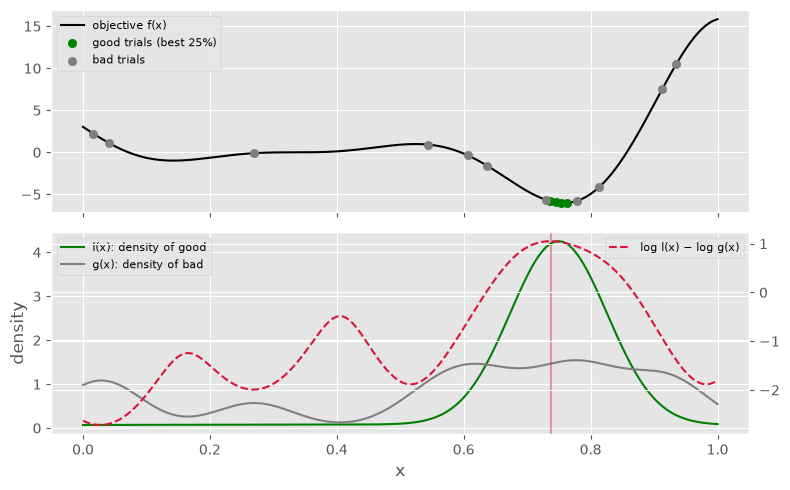

the l/g ratio is highest at x = 0.737 (true minimum at x ≈ 0.757)


In [29]:
rng_view = np.random.default_rng(0)
X15, y15 = tpe_search(forrester, problems["Forrester (1-D)"][1], 15, rng_view)
grid_x = np.linspace(0, 1, 400)[:, None]
order = np.argsort(y15)
n_good = int(np.ceil(0.25 * len(y15)))
good_pts, bad_pts = X15[order[:n_good]], X15[order[n_good:]]
lo_b, hi_b = np.array([0.0]), np.array([1.0])
sig = lambda pts: 0.1 * (hi_b - lo_b) * len(pts) ** (-1 / 5)
log_l = kde_logpdf(grid_x, good_pts, sig(good_pts), lo_b, hi_b)
log_g = kde_logpdf(grid_x, bad_pts, sig(bad_pts), lo_b, hi_b)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(grid_x, forrester(grid_x), color="black", label="objective f(x)")
axes[0].scatter(good_pts, forrester(good_pts), color="green", zorder=3, label="good trials (best 25%)")
axes[0].scatter(bad_pts, forrester(bad_pts), color="grey", zorder=3, label="bad trials")
axes[0].legend(fontsize=8)
axes[1].plot(grid_x, np.exp(log_l), color="green", label="l(x): density of good")
axes[1].plot(grid_x, np.exp(log_g), color="grey", label="g(x): density of bad")
ax_ratio = axes[1].twinx()
ax_ratio.plot(grid_x, log_l - log_g, color="crimson", ls="--", label="log l(x) − log g(x)")
axes[1].axvline(grid_x[np.argmax(log_l - log_g)], color="crimson", alpha=0.4)
axes[1].set(xlabel="x", ylabel="density")
axes[1].legend(loc="upper left", fontsize=8)
ax_ratio.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()
print(f"the l/g ratio is highest at x = {grid_x[np.argmax(log_l - log_g)][0]:.3f} (true minimum at x ≈ 0.757)")

Now the fair race: **20 seeds** per problem, same budget, our random search vs our TPE vs Optuna's TPE. We report the median **regret** (best value found − true minimum; lower is better).

In [30]:
race_rows = []
for name, (f, bounds, f_min, n_trials) in problems.items():
    regrets = {"random (ours)": [], "TPE (ours)": [], "TPE (Optuna)": []}
    for seed in range(20):
        regrets["random (ours)"].append(random_search(f, bounds, n_trials, np.random.default_rng(seed))[1].min() - f_min)
        regrets["TPE (ours)"].append(tpe_search(f, bounds, n_trials, np.random.default_rng(seed))[1].min() - f_min)
        names = [f"x{i}" for i in range(len(bounds))]
        st = optuna.create_study(sampler=optuna.samplers.TPESampler(seed=seed))
        st.optimize(lambda t: float(f(*[t.suggest_float(nm, lo, hi) for nm, (lo, hi) in zip(names, bounds)])), n_trials=n_trials)
        regrets["TPE (Optuna)"].append(st.best_value - f_min)
    wins = int(np.sum(np.array(regrets["TPE (ours)"]) < np.array(regrets["random (ours)"])))
    race_rows.append({"problem": name, "trials": n_trials, **{k: float(np.median(v)) for k, v in regrets.items()}, "our TPE beats random (seeds)": f"{wins}/20"})

race_table = pd.DataFrame(race_rows).set_index("problem")
print(race_table.round(4).to_string())
for row in race_rows:
    assert row["TPE (ours)"] < row["random (ours)"], f"our TPE should beat random search on {row['problem']}"
print("✅ on both problems our ~30-line TPE has a lower median regret than random search with the same budget")

                 trials  random (ours)  TPE (ours)  TPE (Optuna) our TPE beats random (seeds)
problem                                                                                      
Forrester (1-D)      30         0.1866      0.0008        0.0073                        19/20
Branin (2-D)         60         0.5182      0.0449        0.0946                        20/20
✅ on both problems our ~30-line TPE has a lower median regret than random search with the same budget


Optuna's TPE adds more on top: adaptive bandwidths per point, a prior on categorical parameters, multivariate modelling, `constant_liar` for parallel workers, and support for conditional spaces.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Direction doesn't match the returned metric

The old version of this notebook said "return negative AUC" while using `direction="maximize"`. Here's what that does:

In [31]:
def neg_auc_objective(trial):
    params = dict(num_leaves=trial.suggest_int("num_leaves", 2, 64, log=True),
                  learning_rate=trial.suggest_float("learning_rate", 0.001, 0.3, log=True), n_estimators=100)
    model = lgb.LGBMClassifier(verbose=-1, n_jobs=1, random_state=0, **params).fit(small_fit_X, small_fit_y)
    return -roc_auc_score(fresh_y, model.predict_proba(fresh_X)[:, 1])


wrong = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))     # ❌
wrong.optimize(neg_auc_objective, n_trials=20)
right = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))     # ✅ (or return +AUC and maximize)
right.optimize(neg_auc_objective, n_trials=20)
print(f"❌ maximize(-AUC) picks a model with AUC {-wrong.best_value:.4f} ({wrong.best_params})")
print(f"✅ minimize(-AUC) picks a model with AUC {-right.best_value:.4f} ({right.best_params})")

❌ maximize(-AUC) picks a model with AUC 0.7599 ({'num_leaves': 2, 'learning_rate': 0.0016437275723723212})
✅ minimize(-AUC) picks a model with AUC 0.9044 ({'num_leaves': 7, 'learning_rate': 0.03980687048299293})


### ❌ Pitfall 2 — Parameter names that the model silently ignores

In [32]:
def fit_val_auc(params):
    model = lgb.LGBMClassifier(n_estimators=150, verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED, **params).fit(X_train, y_train)
    return model, roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])


typo_model, typo_auc = fit_val_auc({"lr": 0.3, "colsample": 0.5, "leaves": 8})                          # ❌ not LightGBM names
default_model, default_auc = fit_val_auc({})
real_model, real_auc = fit_val_auc({"learning_rate": 0.3, "colsample_bytree": 0.5, "num_leaves": 8})     # ✅
print(f"❌ lr/colsample/leaves → AUC {typo_auc:.4f} | booster learning_rate={typo_model.booster_.params['learning_rate']} "
      f"| identical to defaults: {np.allclose(typo_model.predict_proba(X_val), default_model.predict_proba(X_val))} — and no error or warning")
print(f"✅ learning_rate/colsample_bytree/num_leaves → AUC {real_auc:.4f} | booster learning_rate={real_model.booster_.params['learning_rate']}")

❌ lr/colsample/leaves → AUC 0.9299 | booster learning_rate=0.1 | identical to defaults: True — and no error or warning
✅ learning_rate/colsample_bytree/num_leaves → AUC 0.9293 | booster learning_rate=0.3


### ❌ Pitfall 3 — Learning rate on a linear scale

Section 4 showed that with `suggest_float("lr", 1e-4, 1e-1)` only ~11% of trials try values below 0.01. The fix is one argument: `log=True`.

### ❌ Pitfall 4 — Expecting a seed to make parallel studies reproducible

In [33]:
print("❌ TPESampler(seed=7) with n_jobs=4 twice → same trials:", trial_xs(7, 4) == trial_xs(7, 4))
print("✅ TPESampler(seed=7) with n_jobs=1 twice → same trials:", trial_xs(7, 1) == trial_xs(7, 1))

❌ TPESampler(seed=7) with n_jobs=4 twice → same trials: False
✅ TPESampler(seed=7) with n_jobs=1 twice → same trials: True


### ❌ Pitfall 5 — One invalid configuration kills the whole study

Some combinations are invalid (e.g. `max_depth` smaller than required, out-of-memory batch sizes). An uncaught exception stops `optimize()` immediately. Pass `catch=(...)` so the trial is recorded as `FAIL` and the search continues, or return `float("nan")`.

In [34]:
def fragile_objective(trial):
    x = trial.suggest_float("x", 0, 1)
    if x > 0.7:
        raise ValueError("unsupported configuration")
    return (x - 0.3) ** 2


optuna.logging.set_verbosity(optuna.logging.ERROR)                  # Optuna logs each failed trial as a warning; keep output tidy
crashing = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=0))
try:
    crashing.optimize(fragile_objective, n_trials=30)                                   # ❌
except ValueError as err:
    print(f"❌ without catch: optimize() raised '{err}' after {len(crashing.trials)} of 30 trials")

robust = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=0))
robust.optimize(fragile_objective, n_trials=30, catch=(ValueError,))                    # ✅
states = pd.Series([t.state.name for t in robust.trials]).value_counts().to_dict()
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"✅ with catch=(ValueError,): all 30 trials ran {states}, best x = {robust.best_params['x']:.3f}")

❌ without catch: optimize() raised 'unsupported configuration' after 2 of 30 trials
✅ with catch=(ValueError,): all 30 trials ran {'COMPLETE': 18, 'FAIL': 12}, best x = 0.383


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Minimize a parabola
Create a study that **minimizes** `(x - 3) ** 2` for `x` in `[-10, 10]` with `TPESampler(seed=0)` and 40 trials. Store the best `x`, **rounded to the nearest integer**, in `best_x`.

In [35]:
best_x = None  # TODO
check("best_x", best_x, 3, hint="optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=0)); round(study.best_params['x'])")

⏳ best_x: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
parabola = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))
parabola.optimize(lambda trial: (trial.suggest_float("x", -10, 10) - 3) ** 2, n_trials=40)
best_x = round(parabola.best_params["x"])
check("best_x", best_x, 3)
```
</details>

### 🟢 Exercise 2 — Read a finished study
From `first_study` (Section 3), return a tuple `(best trial number, number of trees it used)`. The tree count was stored with `set_user_attr("best_iteration", ...)`.

In [36]:
best_trial_info = None  # TODO: (int, int)
_winner = max((t for t in first_study.trials if t.state == TrialState.COMPLETE), key=lambda t: t.value)
check("best_trial_info", best_trial_info, (_winner.number, _winner.user_attrs["best_iteration"]),
      hint="first_study.best_trial.number and first_study.best_trial.user_attrs[...]")

⏳ best_trial_info: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_trial_info = (first_study.best_trial.number, first_study.best_trial.user_attrs["best_iteration"])
_winner = max((t for t in first_study.trials if t.state == TrialState.COMPLETE), key=lambda t: t.value)
check("best_trial_info", best_trial_info, (_winner.number, _winner.user_attrs["best_iteration"]))
```
</details>

### 🟢 Exercise 3 — A grid that stops by itself
Run a `GridSampler` over `{"booster": ["gbdt", "dart"], "num_leaves": [15, 31, 63]}` with `n_trials=100` (the objective can return `0.0` after suggesting both parameters). Store the number of trials that actually ran in `grid_trials`.

In [37]:
grid_trials = None  # TODO
check("grid_trials", grid_trials, 6, hint="GridSampler stops the study once every combination has been tried.")

⏳ grid_trials: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
space = {"booster": ["gbdt", "dart"], "num_leaves": [15, 31, 63]}
grid = optuna.create_study(sampler=optuna.samplers.GridSampler(space))
grid.optimize(lambda t: (t.suggest_categorical("booster", space["booster"]), t.suggest_categorical("num_leaves", space["num_leaves"]), 0.0)[-1],
              n_trials=100)
grid_trials = len(grid.trials)
check("grid_trials", grid_trials, 6)
```
</details>

### 🟡 Exercise 4 — Make an objective prunable
`curve_loss(lr, step)` below is a **synthetic** learning curve (a controlled example: the final loss is lowest near `lr = 10**-1.5 ≈ 0.03`). Write `prunable_objective(trial)`: suggest `lr` in `[1e-3, 1]` on a log scale, loop over steps `0…19`, `report` the loss at every step, prune when told, and return the final loss. Run 40 trials with `TPESampler(seed=0)` and `MedianPruner(n_startup_trials=3)`, then store `(some_trials_pruned, best_lr_between_0.01_and_0.1)` as two booleans.

In [38]:
def curve_loss(lr, step):
    return (math.log10(lr) + 1.5) ** 2 + 1.0 / (step + 1)


pruning_result = None  # TODO: (bool, bool)
check("pruning_result", pruning_result, (True, True), hint="trial.report(loss, step); if trial.should_prune(): raise optuna.TrialPruned()")

⏳ pruning_result: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def curve_loss(lr, step):
    return (math.log10(lr) + 1.5) ** 2 + 1.0 / (step + 1)


def prunable_objective(trial):
    lr = trial.suggest_float("lr", 1e-3, 1.0, log=True)
    for step in range(20):
        loss = curve_loss(lr, step)
        trial.report(loss, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return loss


curve_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0),
                                  pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
curve_study.optimize(prunable_objective, n_trials=40)
pruning_result = (any(t.state == TrialState.PRUNED for t in curve_study.trials), 0.01 <= curve_study.best_params["lr"] <= 0.1)
check("pruning_result", pruning_result, (True, True))
```
</details>

### 🟡 Exercise 5 — Pareto front from scratch
Each tuple is `(validation AUC, model size)`. Higher AUC and **smaller** size are better. Return the **sorted list of indices** of the non-dominated points. (A point is dominated if another point is at least as good on both objectives and strictly better on one.)

In [39]:
candidates_mo = [(0.90, 500), (0.92, 800), (0.91, 400), (0.89, 300), (0.92, 900), (0.88, 350)]
pareto_idx = None  # TODO: e.g. [..]
check("pareto_idx", pareto_idx, [1, 2, 3], hint="For each i, check whether any j has auc_j >= auc_i and size_j <= size_i with at least one strict.")

⏳ pareto_idx: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
candidates_mo = [(0.90, 500), (0.92, 800), (0.91, 400), (0.89, 300), (0.92, 900), (0.88, 350)]


def dominates(a, b):
    return a[0] >= b[0] and a[1] <= b[1] and (a[0] > b[0] or a[1] < b[1])


pareto_idx = sorted(i for i, p in enumerate(candidates_mo) if not any(dominates(q, p) for q in candidates_mo))
check("pareto_idx", pareto_idx, [1, 2, 3])
```

This O(n²) check is fine for hundreds of trials; Optuna uses faster non-dominated sorting for large studies.
</details>

### 🔴 Exercise 6 — Successive halving (the heart of Hyperband)
27 configurations have **synthetic** learning curves `score(c, budget)` (higher is better). Implement successive halving with reduction factor 3: give every surviving configuration the budgets `1`, then `3`, then `9`; after each rung keep the top third by score. Return `(winning configuration index, total budget spent)`, where the total budget is the sum of the budgets given at each rung.

In [40]:
rng_sh = np.random.default_rng(5)
true_quality = rng_sh.uniform(0.5, 1.0, size=27)


def score(c, budget):
    return true_quality[c] * (1 - math.exp(-budget / 4)) + 0.005 * math.sin(7 * c + budget)


halving_result = None  # TODO: (int, int)
check("halving_result", halving_result, (int(np.argmax(true_quality)), 27 * 1 + 9 * 3 + 3 * 9),
      hint="survivors = range(27); for budget in (1, 3, 9): rank survivors by score(c, budget), keep len // 3 (at least 1)")

⏳ halving_result: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rng_sh = np.random.default_rng(5)
true_quality = rng_sh.uniform(0.5, 1.0, size=27)


def score(c, budget):
    return true_quality[c] * (1 - math.exp(-budget / 4)) + 0.005 * math.sin(7 * c + budget)


def successive_halving(n_configs=27, budgets=(1, 3, 9), eta=3):
    survivors, spent = list(range(n_configs)), 0
    for budget in budgets:
        scores = {c: score(c, budget) for c in survivors}
        spent += budget * len(survivors)
        survivors = sorted(survivors, key=scores.get, reverse=True)[:max(1, len(survivors) // eta)]
    return survivors[0], spent


halving_result = successive_halving()
check("halving_result", halving_result, (int(np.argmax(true_quality)), 27 * 1 + 9 * 3 + 3 * 9))
```

Talk it through: 81 budget units instead of 27 × 9 = 243 for training everything fully, as long as early scores rank configurations roughly correctly. Hyperband runs several such brackets with different starting budgets to hedge against curves that cross.
</details>

## 🚀 Mini Project: Tuning LightGBM on Adult Income the Right Way

**Goal:** tune LightGBM for ROC-AUC on the Adult census data with **3-fold cross-validation, early stopping inside each fold, and pruning**; compare TPE against **LightGBM defaults** and **random search with the same trial budget**; map the best parameters correctly into a final model retrained on all non-test data; and evaluate **once** on the untouched test set.

**Steps:** folds and baseline → leak-free objective → TPE study (saved to SQLite) → random search at the same budget → compare → final model and single test evaluation → conclusions.

### Step 1 — Folds and a baseline

We tune on **train + validation** (80% of the data) with 3 stratified folds. Inside each fold, 10% of the fold's training rows are held aside for **early stopping**, so the fold's validation rows are used **only** for scoring.

In [41]:
N_FOLDS, BUDGET = 3, 20
folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_trval, y_trval))
fold_splits = []
for tr_idx, va_idx in folds:
    fit_idx, stop_idx = train_test_split(tr_idx, test_size=0.1, stratify=y_trval[tr_idx], random_state=SEED)
    fold_splits.append((fit_idx, stop_idx, va_idx))
assert all(not (set(f) & set(v)) and not (set(s) & set(v)) for f, s, v in fold_splits), "fit/stop rows must not overlap scoring rows"


def cv_auc_defaults():
    scores = []
    for fit_idx, stop_idx, va_idx in fold_splits:
        model = lgb.LGBMClassifier(verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED).fit(X_trval.iloc[fit_idx], y_trval[fit_idx])
        scores.append(roc_auc_score(y_trval[va_idx], model.predict_proba(X_trval.iloc[va_idx])[:, 1]))
    return float(np.mean(scores)), float(np.std(scores))


default_cv, default_cv_std = cv_auc_defaults()
print(f"LightGBM defaults: 3-fold CV AUC {default_cv:.4f} ± {default_cv_std:.4f}")

LightGBM defaults: 3-fold CV AUC 0.9269 ± 0.0025


### Step 2 — A leak-free, prunable objective

One `project_params` function defines the search space **and** rebuilds the final parameters (Section 11). After each fold we report the running mean AUC, so the `MedianPruner` can stop a trial whose first folds are clearly worse than other trials' first folds.

In [42]:
PROJECT_FIXED = dict(subsample_freq=1, verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED)


def project_params(trial_or_params):
    t = trial_or_params if not isinstance(trial_or_params, dict) else optuna.trial.FixedTrial(trial_or_params)
    return {
        "learning_rate": t.suggest_float("learning_rate", 0.02, 0.3, log=True),
        "num_leaves": t.suggest_int("num_leaves", 8, 256, log=True),
        "min_child_samples": t.suggest_int("min_child_samples", 5, 200, log=True),
        "subsample": t.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": t.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_lambda": t.suggest_float("reg_lambda", 1e-3, 30.0, log=True),
        **PROJECT_FIXED,
    }


def project_objective(trial):
    params = project_params(trial)
    fold_scores, fold_trees = [], []
    for k, (fit_idx, stop_idx, va_idx) in enumerate(fold_splits):
        model = lgb.LGBMClassifier(n_estimators=2000, **params)
        model.fit(X_trval.iloc[fit_idx], y_trval[fit_idx], eval_X=X_trval.iloc[stop_idx], eval_y=y_trval[stop_idx],
                  eval_metric="auc", callbacks=[lgb.early_stopping(50, verbose=False)])
        fold_scores.append(roc_auc_score(y_trval[va_idx], model.predict_proba(X_trval.iloc[va_idx])[:, 1]))
        fold_trees.append(model.best_iteration_)
        trial.report(float(np.mean(fold_scores)), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("n_estimators", int(np.mean(fold_trees)))
    trial.set_user_attr("fold_std", float(np.std(fold_scores)))
    return float(np.mean(fold_scores))

### Step 3 — TPE study, saved to SQLite

The first trial is **enqueued** with LightGBM-like default values, so the search starts from a known-good point.

In [43]:
for name in ("adult-lgbm-tpe", "adult-lgbm-random"):
    if name in optuna.get_all_study_names(STORAGE):
        optuna.delete_study(study_name=name, storage=STORAGE)

DEFAULT_LIKE = {"learning_rate": 0.1, "num_leaves": 31, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 0.001}


def run_project_study(name, sampler):
    study = optuna.create_study(study_name=name, storage=STORAGE, direction="maximize", sampler=sampler,
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
    study.enqueue_trial(DEFAULT_LIKE)
    start = time.perf_counter()
    study.optimize(project_objective, n_trials=BUDGET)
    return study, time.perf_counter() - start


tpe_project, tpe_seconds = run_project_study("adult-lgbm-tpe", optuna.samplers.TPESampler(seed=SEED))
tpe_states = pd.Series([t.state.name for t in tpe_project.trials]).value_counts().to_dict()
print(f"TPE: {BUDGET} trials in {tpe_seconds:.0f}s {tpe_states} | best CV AUC {tpe_project.best_value:.4f}")

TPE: 20 trials in 83s {'COMPLETE': 15, 'PRUNED': 5} | best CV AUC 0.9280


### Step 4 — Random search with the same budget

Same objective, same pruner, same enqueued first trial, same 20 trials — only the sampler differs.

In [44]:
random_project, random_seconds = run_project_study("adult-lgbm-random", optuna.samplers.RandomSampler(seed=SEED))
random_states = pd.Series([t.state.name for t in random_project.trials]).value_counts().to_dict()
print(f"Random: {BUDGET} trials in {random_seconds:.0f}s {random_states} | best CV AUC {random_project.best_value:.4f}")

Random: 20 trials in 60s {'COMPLETE': 11, 'PRUNED': 9} | best CV AUC 0.9276


### Step 5 — Compare on cross-validation (still no test set)

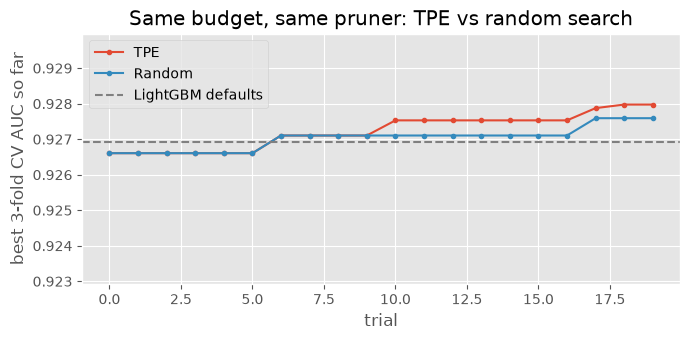

               CV AUC  fold std  pruned trials  seconds
defaults       0.9269    0.0025              0      NaN
random search  0.9276    0.0026              9  59.7323
TPE            0.9280    0.0025              5  82.7413

🏆 chosen by CV (before any test evaluation): TPE | params {'learning_rate': 0.020830721047042117, 'num_leaves': 38, 'min_child_samples': 5, 'subsample': 0.8613720388279502, 'colsample_bytree': 0.7095092165869399, 'reg_lambda': 0.16638101075330622} | trees ≈ 431


In [45]:
def best_so_far(study):
    values = [t.value if t.state == TrialState.COMPLETE else -np.inf for t in study.trials]
    return np.maximum.accumulate(values)


fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(best_so_far(tpe_project), marker="o", ms=3, label="TPE")
ax.plot(best_so_far(random_project), marker="o", ms=3, label="Random")
ax.axhline(default_cv, color="grey", ls="--", label="LightGBM defaults")
ax.set(xlabel="trial", ylabel="best 3-fold CV AUC so far", title="Same budget, same pruner: TPE vs random search")
ax.set_ylim(default_cv - 0.004, max(tpe_project.best_value, random_project.best_value) + 0.002)
ax.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "CV AUC": [default_cv, random_project.best_value, tpe_project.best_value],
    "fold std": [default_cv_std, random_project.best_trial.user_attrs["fold_std"], tpe_project.best_trial.user_attrs["fold_std"]],
    "pruned trials": [0, random_states.get("PRUNED", 0), tpe_states.get("PRUNED", 0)],
    "seconds": [np.nan, random_seconds, tpe_seconds],
}, index=["defaults", "random search", "TPE"])
print(comparison.round(4))

winner_name = "TPE" if tpe_project.best_value >= random_project.best_value else "random search"
winner_study = tpe_project if winner_name == "TPE" else random_project
print(f"\n🏆 chosen by CV (before any test evaluation): {winner_name} | params {winner_study.best_params} | "
      f"trees ≈ {winner_study.best_trial.user_attrs['n_estimators']}")

### Step 6 — Final model and the one test evaluation

Rebuild the exact parameters with `project_params(best_params)`, add the tree count found by early stopping (scaled by 1.1 because the final model sees ~10% more rows than each fold's fit set), retrain on **all** train + validation rows, and score the test set once. The defaults model, trained on the same rows, is the reference.

In [46]:
winner_trial = winner_study.best_trial
final_project_params = project_params(winner_trial.params) | {"n_estimators": int(round(winner_trial.user_attrs["n_estimators"] * 1.1))}
tuned_final = lgb.LGBMClassifier(**final_project_params).fit(X_trval, y_trval)
default_final = lgb.LGBMClassifier(verbose=-1, n_jobs=LGBM_THREADS, random_state=SEED).fit(X_trval, y_trval)

booster_check = tuned_final.booster_.params
assert all(math.isclose(float(booster_check[k]), float(final_project_params[k])) for k in ("learning_rate", "num_leaves", "subsample", "colsample_bytree", "reg_lambda"))
print("✅ tuned values confirmed inside the trained booster (no silently ignored names)")

tuned_proba = tuned_final.predict_proba(X_test)[:, 1]
default_proba = default_final.predict_proba(X_test)[:, 1]
test_results = pd.DataFrame({
    "test ROC-AUC": [roc_auc_score(y_test, default_proba), roc_auc_score(y_test, tuned_proba)],
    "test log-loss": [log_loss(y_test, default_proba), log_loss(y_test, tuned_proba)],
    "CV AUC (tuning estimate)": [default_cv, winner_trial.value],
}, index=["defaults", f"tuned ({winner_name})"])
print(test_results.round(4))

# bootstrap the test set to see whether the AUC difference is bigger than sampling noise
rng_boot = np.random.default_rng(SEED)
boot_diffs = []
for _ in range(300):
    idx = rng_boot.integers(0, len(y_test), len(y_test))
    boot_diffs.append(roc_auc_score(y_test[idx], tuned_proba[idx]) - roc_auc_score(y_test[idx], default_proba[idx]))
diff_low, diff_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"tuned − defaults test AUC: {np.mean(boot_diffs):+.4f} (95% bootstrap interval {diff_low:+.4f} to {diff_high:+.4f})")

✅ tuned values confirmed inside the trained booster (no silently ignored names)
             test ROC-AUC  test log-loss  CV AUC (tuning estimate)
defaults           0.9298         0.2739                    0.9269
tuned (TPE)        0.9303         0.2728                    0.9280


tuned − defaults test AUC: +0.0005 (95% bootstrap interval -0.0001 to +0.0012)


### Step 7 — Conclusions (computed)

In [47]:
tuned_test_auc = test_results.iloc[1]["test ROC-AUC"]
default_test_auc = test_results.iloc[0]["test ROC-AUC"]
print(f"1. With {BUDGET} trials each, TPE reached CV AUC {tpe_project.best_value:.4f} and random search {random_project.best_value:.4f} "
      f"→ {'TPE ahead' if tpe_project.best_value > random_project.best_value + 0.0005 else 'random search ahead' if random_project.best_value > tpe_project.best_value + 0.0005 else 'practically tied'} at this small budget.")
folds_before_prune = sorted({len(t.intermediate_values) for st in (tpe_project, random_project) for t in st.trials if t.state == TrialState.PRUNED})
print(f"2. Pruning stopped {tpe_states.get('PRUNED', 0)} TPE and {random_states.get('PRUNED', 0)} random trials after {folds_before_prune} of {N_FOLDS} folds.")
print(f"3. Tuned CV AUC {winner_trial.value:.4f} vs defaults {default_cv:.4f} (+{winner_trial.value - default_cv:.4f}).")
significant = diff_low > 0
print(f"4. On the untouched test set: tuned {tuned_test_auc:.4f} vs defaults {default_test_auc:.4f}; the 95% bootstrap interval of the difference "
      f"{'excludes' if significant else 'includes'} zero → {'a real but modest improvement' if significant else 'the gain is within test-set noise'}.")
optimism = winner_trial.value - tuned_test_auc
print(f"5. CV estimate minus test AUC for the tuned model: {optimism:+.4f} → "
      f"{'the CV estimate was reliable' if abs(optimism) < 0.005 else 'a noticeable gap: expect some winner’s-curse optimism'}.")

1. With 20 trials each, TPE reached CV AUC 0.9280 and random search 0.9276 → practically tied at this small budget.
2. Pruning stopped 5 TPE and 9 random trials after [1] of 3 folds.
3. Tuned CV AUC 0.9280 vs defaults 0.9269 (+0.0010).
4. On the untouched test set: tuned 0.9303 vs defaults 0.9298; the 95% bootstrap interval of the difference includes zero → the gain is within test-set noise.
5. CV estimate minus test AUC for the tuned model: -0.0023 → the CV estimate was reliable.


**Stretch goals**
1. Replace ROC-AUC with **log-loss** and add a second objective, **prediction latency** on 1,000 rows, then choose from the Pareto front.
2. Use **nested CV** (an outer loop around the whole tuning procedure) to get an unbiased estimate of "tuned LightGBM" on this data.
3. Run the study from **two terminal processes** sharing the SQLite file (or a `JournalStorage`) and compare wall time.
4. Try `HyperbandPruner` with boosting rounds as the resource (Section 6's callback) instead of folds.
5. Open the study in `optuna-dashboard sqlite:///_outputs/optuna/studies.db` (`pip install optuna-dashboard`).

### 🗣️ How to talk about this in an interview
- "I tuned LightGBM with Optuna's TPE on 3-fold stratified CV. Early stopping used a slice of each fold's training rows, so the scoring rows were never used for any fitting decision, and the test set was scored once at the end."
- "I reported the running mean AUC after each fold and used a MedianPruner, which cut unpromising trials before all folds had run."
- "To see whether Bayesian search mattered, I ran random search with the same 20-trial budget, pruner and starting point, and compared both to LightGBM's defaults."
- "One function defined the search space and rebuilt the final parameters, and I asserted the values inside the trained booster. That avoids the classic bug where names like `lr` are silently ignored."
- "I bootstrapped the test set to check whether the tuned model's gain was larger than sampling noise, and I stated how far the CV estimate was from the test score."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why does random search usually beat grid search?**

<details><summary>Show answer</summary>

- **30-second answer:** Usually only a few hyperparameters matter. With the same number of trials, a grid tests only a handful of distinct values per hyperparameter, while random search tests a new value every trial, so it covers the important dimensions much better (Bergstra & Bengio, 2012). It's also trivially parallel and can be stopped at any time.
- **Go deeper:** A 3×3 grid tries 3 values of each knob; 9 random trials try 9. Grid cost grows exponentially with the number of hyperparameters. Grid still makes sense for 1–2 cheap discrete knobs or reproducing a paper's sweep.
- **❌ Common wrong answer:** "Grid search is better because it is exhaustive" — it is only exhaustive over the points you listed.

</details>

**Q2. Explain how TPE works.**

<details><summary>Show answer</summary>

- **30-second answer:** After some random start-up trials, TPE splits past trials by a quantile γ into "good" and "bad", fits one density $l(x)$ to the good hyperparameters and one $g(x)$ to the bad ones, samples candidates from $l(x)$, and evaluates the candidate with the highest $l(x)/g(x)$. Maximizing that ratio is equivalent to maximizing expected improvement under TPE's model.
- **Go deeper:** The densities are Parzen (kernel) estimators, one per parameter (independent TPE) or joint (multivariate, Optuna's default for single-objective studies in 5.0). The tree structure lets it handle conditional parameters. It is cheap (no matrix inversions like GP-based BO) and handles categorical values. `constant_liar` avoids duplicate suggestions in parallel.
- **❌ Common wrong answer:** "TPE fits a Gaussian process to the objective" — that's GP-based Bayesian optimization.

</details>

**Q3. What is pruning, and how is it different from early stopping?**

<details><summary>Show answer</summary>

- **30-second answer:** Early stopping ends *one* training run when its own validation metric stops improving. Pruning ends a *trial* because its intermediate results are worse than those of *other trials* at the same step (e.g. below the median), so compute goes to promising configurations.
- **Go deeper:** In Optuna: `trial.report(value, step)` + `trial.should_prune()` → `raise TrialPruned()`. `MedianPruner` is the default pruner of `create_study`; `n_startup_trials` and `n_warmup_steps` avoid pruning on too little evidence. Pruning assumes early scores rank configurations reasonably well — a slow-starting, low learning rate can be pruned unfairly.
- **❌ Common wrong answer:** "They're the same thing" or "the default pruner is NopPruner."

</details>

**Q4. How do successive halving and Hyperband work?**

<details><summary>Show answer</summary>

- **30-second answer:** Successive halving gives many configurations a small budget, keeps the top 1/η, multiplies the budget by η and repeats. Hyperband runs several successive-halving brackets with different trade-offs between the number of configurations and the starting budget, so it works even when you don't know how early scores relate to final scores.
- **Go deeper:** In Exercise 6, 27 configs at budgets 1/3/9 cost 81 units instead of 243. ASHA is the asynchronous variant that suits many parallel workers. BOHB combines Hyperband's budgets with TPE-style model-based sampling.
- **❌ Common wrong answer:** "Hyperband is a Bayesian optimizer" — on its own it samples configurations randomly.

</details>

**Q5. How do you avoid leakage when tuning hyperparameters?**

<details><summary>Show answer</summary>

- **30-second answer:** Score trials with cross-validation or a validation split, never the test set. Fit all preprocessing and early stopping inside each training fold. Freeze every decision, then evaluate on the test set exactly once. For time series, use time-ordered splits.
- **Go deeper:** Nested CV gives an unbiased estimate of the whole tuning procedure. In the mini project, early stopping used a slice of each fold's training rows so the scoring rows never influenced fitting. Repeatedly peeking at test results after changing the search space is leakage too.
- **❌ Common wrong answer:** "It's fine to early-stop on the test set because the test set isn't used for training."

</details>

**Q6. What does "overfitting the validation set" mean?**

<details><summary>Show answer</summary>

- **30-second answer:** When you compare many configurations on the same validation data, the winner is partly chosen for luck on those rows, so its validation score is optimistically biased. The more trials and the smaller the validation set, the bigger the bias (the winner's curse).
- **Go deeper:** Section 10 measured it: we compared each winner's tuning score with its AUC on fresh data (its rank among all configurations, and how much more flattered it was than the average trial) for a 200-row split vs 5-fold CV. Mitigations: larger validation sets or CV, fewer and better-chosen trials, repeated CV, nested CV, a final untouched test set, and comparing gains with seed/fold noise.
- **❌ Common wrong answer:** "It can't happen, because the model never trains on validation data."

</details>

**Q7. When is hyperparameter tuning *not* worth it?**

<details><summary>Show answer</summary>

- **30-second answer:** When the defaults are already strong and the gain would be within noise (we saw GBM defaults within ~seed noise of a hand-tuned setting on Adult), when data or features are the real bottleneck, when the dataset is too small to measure differences reliably, or when compute and time cost more than the improvement is worth.
- **Go deeper:** Get a baseline, measure noise (seeds, folds), fix obvious data issues first, then tune the few parameters that matter with a small budget. Bigger wins often come from better features, more data, or the right loss/metric.
- **❌ Common wrong answer:** "Always run 1,000 trials; more tuning is always better."

</details>

**Q8. How would you tune for accuracy *and* latency?**

<details><summary>Show answer</summary>

- **30-second answer:** A multi-objective study (`directions=["maximize", "minimize"]`) returns the Pareto front of trade-offs; then apply an explicit rule such as "smallest model within 0.002 AUC of the best" or "best AUC with p95 latency ≤ 20 ms". Alternatively, optimize accuracy with latency as a constraint.
- **Go deeper:** Optuna uses multi-objective TPE by default for multiple directions, or `NSGAIISampler`. `study.best_trials` holds the Pareto set, and `best_trial` raises an error. Measure latency on production hardware and batch sizes. Model size (total leaves, parameters) is a cheap proxy while searching.
- **❌ Common wrong answer:** "Add accuracy and latency together into one score" without justifying the weights or units.

</details>

**Q9. Which sampler would you choose, and why?**

<details><summary>Show answer</summary>

- **30-second answer:** TPE for most problems (fast, handles categorical and conditional spaces). A Gaussian-process sampler for small budgets of expensive, mostly continuous parameters. CMA-ES for many trials in continuous spaces. Random search as a baseline and for massive parallelism. NSGA-II or MOTPE for multiple objectives. Grid for tiny exhaustive sweeps.
- **Go deeper:** Samplers only matter if trials are informative. With large parallelism, model-based samplers see fewer completed results, so random + an aggressive pruner (ASHA) can be competitive. In our Branin race, TPE and GP far outperformed random and grid at 40 trials.
- **❌ Common wrong answer:** "Bayesian optimization is always best" — it's sequential and has overhead that matters with cheap objectives or many workers.

</details>

### 💻 Coding

**Q10. Write an Optuna objective for LightGBM with a log-scaled learning rate, early stopping and pruning.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def objective(trial):
      params = {"learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 8, 256, log=True)}
      scores = []
      for k, (tr, va) in enumerate(folds):
          m = lgb.LGBMClassifier(n_estimators=2000, verbose=-1, **params)
          m.fit(X.iloc[tr], y[tr], eval_X=X.iloc[va], eval_y=y[va], callbacks=[lgb.early_stopping(50, verbose=False)])
          scores.append(roc_auc_score(y[va], m.predict_proba(X.iloc[va])[:, 1]))
          trial.report(np.mean(scores), k)
          if trial.should_prune():
              raise optuna.TrialPruned()
      return np.mean(scores)
  study = optuna.create_study(direction="maximize")
  ```
- **Go deeper:** Early-stop on a slice of the training fold (as in the mini project) if you want the scoring rows completely untouched. Store `best_iteration_` with `trial.set_user_attr`. In LightGBM 4.7's sklearn API use `eval_X`/`eval_y`.
- **❌ Common wrong answer:** Returning `-auc` with `direction="maximize"`, or early stopping on the test set.

</details>

**Q11. After tuning, a teammate trains `LGBMClassifier(**study.best_params)` and the model behaves exactly like the defaults. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** The keys in `best_params` are whatever names were passed to `suggest_*` (e.g. `lr`, `colsample`). LightGBM doesn't recognize them and, with `verbose=-1`, silently ignores them. Also, fixed parameters (`subsample_freq`) and the early-stopping tree count aren't in `best_params` at all.
- **Go deeper:** Use the real argument names in `suggest_*`, build parameters with one shared function (`FixedTrial` makes it reusable), and assert the values in `model.booster_.params` after fitting. Pitfall 2 showed predictions identical to the defaults.
- **❌ Common wrong answer:** "Optuna's best parameters don't generalize" — here they were never applied.

</details>

### 🐛 Debugging Scenarios

**Q12. Your study with `n_jobs=8` gives different results on every run despite `TPESampler(seed=42)`. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** With parallel trials, the order in which trials finish depends on thread timing, so the sampler conditions on different histories. A seed only makes *sequential* studies reproducible. The model's own randomness (`random_state`, thread count) matters too.
- **Go deeper:** For exact reproducibility run `n_jobs=1`, seed both the sampler and the model, and record the Optuna and library versions. For large parallel searches, accept non-determinism and store every trial in a database so results are auditable.
- **❌ Common wrong answer:** "Optuna ignores the seed."

</details>

**Q13. A long study crashed after 300 of 500 trials, and every result is gone. How do you prevent this?**

<details><summary>Show answer</summary>

- **30-second answer:** Use persistent storage: `create_study(study_name=..., storage="sqlite:///studies.db", load_if_exists=True)`, then re-run to resume. Pass `catch=(...)` so one invalid configuration doesn't raise out of `optimize()`, and consider a heartbeat so stale `RUNNING` trials are marked failed.
- **Go deeper:** For several processes on one machine use `JournalStorage(JournalFileBackend(...))`, and for many machines PostgreSQL/MySQL through `RDBStorage`. `optuna-dashboard` reads the same storage for live monitoring. `gc_after_trial=True` helps with memory growth in long runs.
- **❌ Common wrong answer:** "Pickle the study object at the end" — a crash happens before the end.

</details>

### 🏗️ Design

**Q14. Design hyperparameter tuning for a model that takes 2 GPU-hours per full training run, with 16 GPUs and one week.**

<details><summary>Show answer</summary>

- **30-second answer:** Budget: ~16 × 168 ≈ 2,700 GPU-hours ≈ 1,300 full runs, but use multi-fidelity: ASHA/Hyperband on epochs (or data subsets) so most configurations stop after a few epochs. Shared storage (PostgreSQL), 16 workers, TPE with `constant_liar` (or random sampling for early exploration), a small search space built from known-good ranges, and checkpointing so pruned or preempted runs don't waste compute.
- **Go deeper:** First run a cheap proxy study (smaller model or data) to find sensitive parameters and sensible ranges. Tune learning rate, warm-up and weight decay on a log scale, and fix architecture choices that are known to work. Use a fixed validation set sized for low noise, re-run the top 3 configurations with different seeds before choosing, and score the test set once. Track everything in MLflow/W&B.
- **❌ Common wrong answer:** "Grid search over 6 hyperparameters with 5 values each" (15,625 runs) or "Tune on the test set to save time."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** Which pruner does `optuna.create_study()` use if you don't pass one?
<details><summary>Answer</summary>

`MedianPruner` — printed in Section 6. It only acts if the objective calls `trial.report()` and `trial.should_prune()`.
</details>

**2.** A `GridSampler` over `{"a": [1, 2, 3], "b": ["x", "y"]}` is run with `n_trials=100`. How many trials run?
<details><summary>Answer</summary>

**6** — the study stops once every grid point has been evaluated (Exercise 3 uses this).
</details>

**3.** `lgb.LGBMClassifier(lr=0.3).fit(X, y).booster_.params["learning_rate"]`
<details><summary>Answer</summary>

`0.1` — `lr` isn't a LightGBM parameter, so the default learning rate is used (Pitfall 2).
</details>

**4.** What does `study.best_trial` do on a study created with `directions=["maximize", "minimize"]`?
<details><summary>Answer</summary>

It raises `RuntimeError` ("A single best trial cannot be retrieved from a multi-objective study"). Use `study.best_trials` (Section 8).
</details>

**5.** With `suggest_float("lr", 1e-4, 1e-1)` (no `log=True`), roughly what share of random samples fall below 0.01?
<details><summary>Answer</summary>

About **10%** (we measured 10.7% in Section 4), because 0.0001–0.01 is only a tenth of the linear range. With `log=True` it's about two thirds.
</details>

## 📚 Resources

### 📖 Official Docs
- [Optuna documentation](https://optuna.readthedocs.io/en/stable/) — API reference for the version used here
- [Optuna tutorial](https://optuna.readthedocs.io/en/stable/tutorial/index.html) — key features and recipes, step by step
- [optuna.samplers](https://optuna.readthedocs.io/en/stable/reference/samplers/index.html) — every sampler, with a comparison table of what each supports
- [optuna.pruners](https://optuna.readthedocs.io/en/stable/reference/pruners.html) — MedianPruner, Hyperband, successive halving and more
- [Saving/Resuming Study with RDB Backend](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/001_rdb.html) · [Multi-objective Optimization with Optuna](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/002_multi_objective.html)
- [Quick Visualization for Hyperparameter Optimization Analysis](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/005_visualization.html) — all the plots in Section 9
- [Optuna FAQ](https://optuna.readthedocs.io/en/stable/faq.html) — reproducibility, parallelism, handling failures
- [LightGBM Parameters](https://lightgbm.readthedocs.io/en/stable/Parameters.html) — the real parameter names and aliases
- [scikit-learn — Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html) — grid/random search and successive halving in scikit-learn

### 🎥 Videos
- [Abhishek Thakur — Hyperparameter Optimization: This Tutorial Is All You Need](https://www.youtube.com/watch?v=5nYqK-HaoKY) (~60 min) — grid, random, Bayesian optimization and Optuna on a real dataset, from a Kaggle Grandmaster
- [Probabl — Optuna: a hyperparameter optimization framework](https://www.youtube.com/watch?v=QejQVLkkgRA) (~61 min) — a walkthrough of Optuna's design (define-by-run, samplers, pruners) from the scikit-learn company's channel
- [CampusX — Hyperparameter Tuning using Optuna | Bayesian Optimization using Optuna](https://www.youtube.com/watch?v=E2b3SKMw934) (~59 min) — a slower, beginner-friendly explanation of Bayesian optimization with code

### 📄 Papers
- [Akiba et al. (2019) — Optuna: A Next-generation Hyperparameter Optimization Framework](https://arxiv.org/abs/1907.10902) — define-by-run search spaces, pruning and the system design
- [Bergstra et al. (2011) — Algorithms for Hyper-Parameter Optimization](https://papers.nips.cc/paper/4443-algorithms-for-hyper-parameter-optimization) — the original TPE paper
- [Bergstra & Bengio (2012) — Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/v13/bergstra12a.html) — why random beats grid
- [Watanabe (2023) — Tree-Structured Parzen Estimator: Understanding Its Algorithm Components and Their Roles for Better Empirical Performance](https://arxiv.org/abs/2304.11127) — a modern, detailed look at TPE's design choices
- [Li et al. (2016) — Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization](https://arxiv.org/abs/1603.06560) · [Li et al. (2018) — A System for Massively Parallel Hyperparameter Tuning (ASHA)](https://arxiv.org/abs/1810.05934)
- [Falkner, Klein & Hutter (2018) — BOHB: Robust and Efficient Hyperparameter Optimization at Scale](https://proceedings.mlr.press/v80/falkner18a.html) — Hyperband + model-based sampling

### 📘 Books & Courses
- [Automated Machine Learning: Methods, Systems, Challenges (free book)](https://www.automl.org/book/) — Hutter, Kotthoff & Vanschoren; chapter 1 covers hyperparameter optimization in depth

### 🏋️ Practice
- [optuna-examples](https://github.com/optuna/optuna-examples) — official examples for PyTorch, LightGBM, XGBoost, scikit-learn, distributed runs and more
- [OptunaHub](https://hub.optuna.org/) — community samplers and visualizations to try on your own studies
- [Kaggle Learn — Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) — practise validation, leakage and XGBoost tuning on real competitions

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Study / trial | one optimization run / one evaluation | `optuna.create_study(direction=...)`, `study.optimize(obj, n_trials=...)` |
| Search space | define-by-run suggestions | `suggest_float(..., log=True)`, `suggest_int`, `suggest_categorical`, `if` for conditional params |
| Grid vs random vs TPE | exhaustive / independent / model-based | `GridSampler`, `RandomSampler(seed)`, `TPESampler(seed)` (default) |
| TPE | sample where good/bad density ratio is high | split at quantile γ, maximize $l(x)/g(x)$ |
| Pruning | stop trials worse than others at the same step | `trial.report(v, step)`, `trial.should_prune()`, `MedianPruner` (default), `HyperbandPruner` |
| Storage & resume | persist trials; share between workers | `storage="sqlite:///..."`, `load_if_exists=True`, `optuna.load_study`, `JournalStorage` |
| Parallelism | threads or processes | `n_jobs=k` (GIL-releasing objectives), many processes on one storage |
| Reproducibility | same trials again | seed the sampler **and** the model, `n_jobs=1` |
| Multi-objective | Pareto trade-offs | `directions=[...]`, `study.best_trials`, `plot_pareto_front` |
| Visualization | diagnose the search | `optuna.visualization.matplotlib.plot_optimization_history / plot_param_importances / plot_slice / plot_contour` |
| No leakage | honest estimates | CV inside the objective, early stopping inside folds, test set once, nested CV |
| Best trial → model | apply params correctly | one `build_params` function + `FixedTrial`, add fixed params + `user_attrs["n_estimators"]`, assert `booster_.params` |
| Robustness | keep studies alive | `catch=(Exception,)`, `enqueue_trial(defaults)`, `gc_after_trial=True` |

## ➡️ What's Next

**[02 · Ray Tune](02_Ray_Tune.ipynb)** — the same ideas (samplers, ASHA/Hyperband schedulers, multi-objective search) scaled across many processes and machines with Ray's `Tuner` API, including running Optuna's TPE as a Ray Tune search algorithm.